In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224")

for item in DATA_ROOT.iterdir():
    print(item)

labels_csv = DATA_ROOT / "Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv"
df = pd.read_csv(labels_csv, header=None)
print(df.shape)
print(df.head())

df.columns = [f"feature_{i}" for i in range(29)] + ["label", "flare_size", "filename"]
print(df["label"].value_counts())

/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Train_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Validation_data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/README.md
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/List_of_AR_in_Test_Data_by_AR.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_C1.0_24hr_png_224_features.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Validation_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Train_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Test_Data_by_AR_png_224.csv
/kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/C1.0_24hr_224_png_Labels.txt
(950047, 32)
         0         1   

label
0    759465
1    190582
Name: count, dtype: int64
label
0    79.94
1    20.06
Name: count, dtype: float64


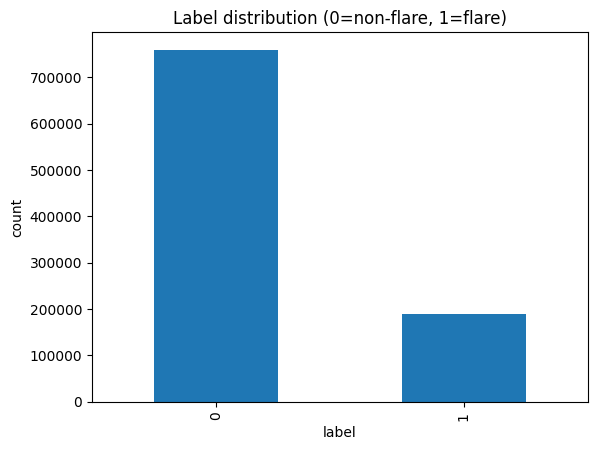

Number of unique ARs: 1570
count    1570.000000
mean      605.125478
std       316.406007
min         3.000000
25%       335.250000
50%       633.500000
75%       915.000000
max      1080.000000
dtype: float64


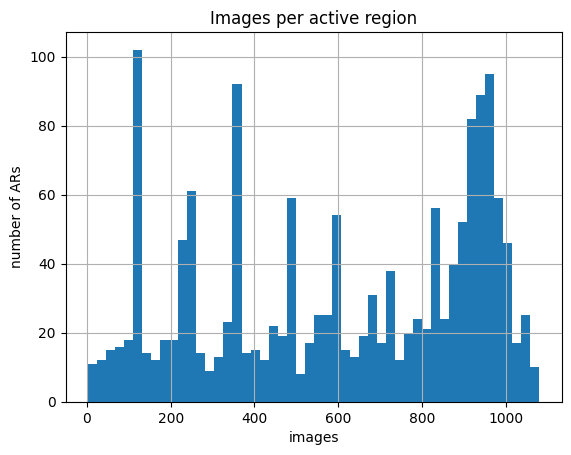

  AR_number    timestamp_str
0      1064  20100501_000000
1      1064  20100501_001200
2      1064  20100501_002400
3      1064  20100501_003600
4      1064  20100501_004800
5      1064  20100501_010000
6      1064  20100501_011200
7      1064  20100501_012400
8      1064  20100501_013600
9      1064  20100501_014800


In [2]:
import matplotlib.pyplot as plt

# --- Class balance ---
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

plt.figure()
counts.plot(kind="bar")
plt.title("Label distribution (0=non-flare, 1=flare)")
plt.xlabel("label"); plt.ylabel("count")
plt.show()

# --- Extract AR number from filename (first part before underscore) ---
df["AR_number"] = df["filename"].str.split("_").str[0]
per_ar = df.groupby("AR_number").size()
print("Number of unique ARs:", len(per_ar))
print(per_ar.describe())

plt.figure()
per_ar.hist(bins=50)
plt.title("Images per active region")
plt.xlabel("images"); plt.ylabel("number of ARs")
plt.show()

# --- Extract timestamp from filename for temporal check ---
df["timestamp_str"] = df["filename"].str.extract(r"(\d{8}_\d{6})")
print(df[["AR_number", "timestamp_str"]].head(10))

In [3]:
IMAGE_ROOT_REAL = DATA_ROOT / "Lat60_Lon60_Nans0_png_224" / "Lat60_Lon60_Nans0_png_224"

sample_row = df.iloc[0]
sample_path = IMAGE_ROOT_REAL / sample_row["AR_number"] / sample_row["filename"]
print("Testing path:", sample_path)
print("Exists:", sample_path.exists())

if sample_path.exists():
    img = Image.open(sample_path)
    arr = np.array(img)
    print("Size:", img.size, "Mode:", img.mode, "dtype:", arr.dtype)
    print("Min:", arr.min(), "Max:", arr.max(), "Mean:", arr.mean())

Testing path: /kaggle/input/datasets/esayasmelaku/solar-flare-boucheron-c1-224/Lat60_Lon60_Nans0_png_224/Lat60_Lon60_Nans0_png_224/1064/1064_hmi.M_720s.20100501_000000_TAI.1.magnetogram_224.png
Exists: True
Size: (224, 224) Mode: L dtype: uint8
Min: 70 Max: 172 Mean: 127.51094148596938


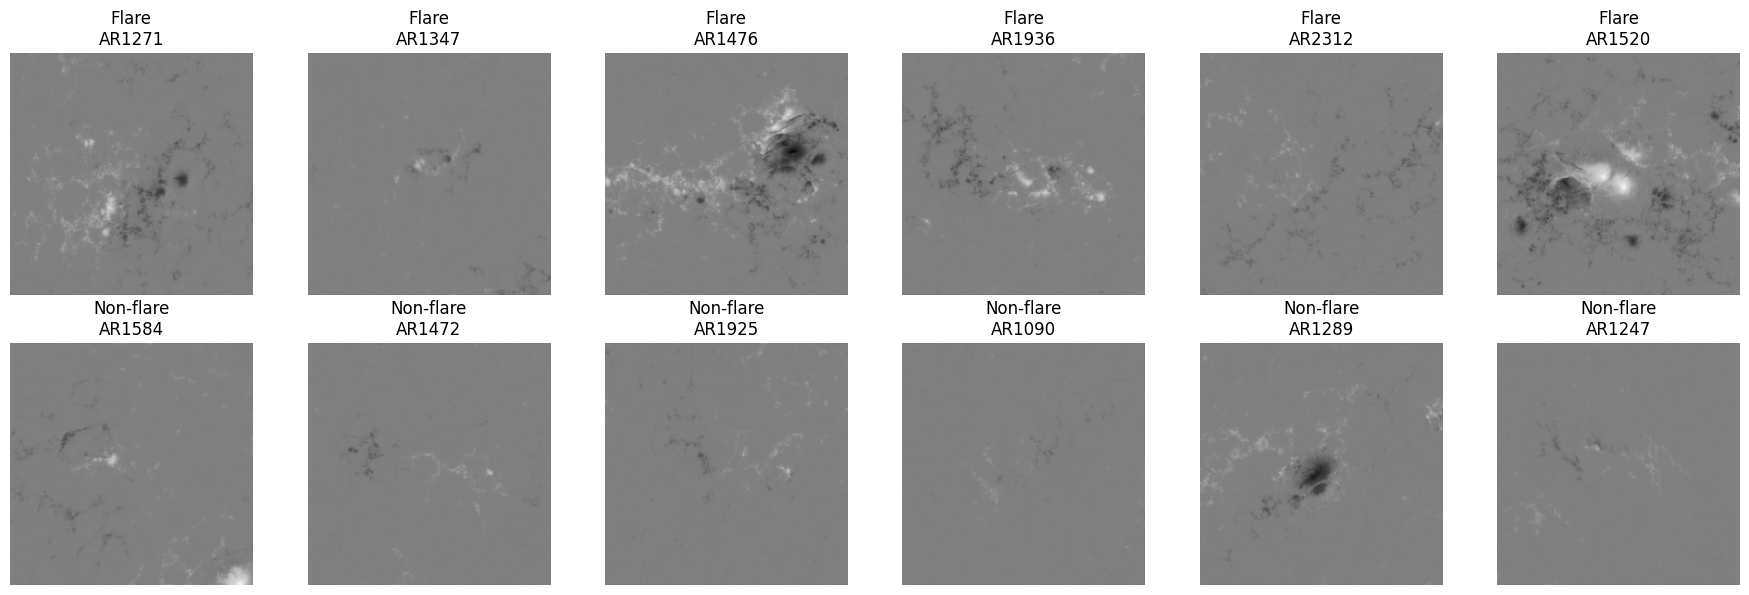

In [4]:
import matplotlib.pyplot as plt

def get_image_path(row):
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

# Sample 6 flare and 6 non-flare images
flare_sample = df[df["label"] == 1].sample(6, random_state=1)
nonflare_sample = df[df["label"] == 0].sample(6, random_state=1)

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, (_, row) in enumerate(flare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[0, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(f"Flare\nAR{row['AR_number']}")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(nonflare_sample.iterrows()):
    p = get_image_path(row)
    img = np.array(Image.open(p))
    axes[1, i].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1, i].set_title(f"Non-flare\nAR{row['AR_number']}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import hashlib
from collections import defaultdict

# Sample 300 images for corruption/duplicate check (checking all 950k would take too long)
check_sample = df.sample(300, random_state=42)

corrupted = []
hashes = defaultdict(list)

for _, row in check_sample.iterrows():
    p = get_image_path(row)
    if not p.exists():
        corrupted.append((str(p), "missing"))
        continue
    try:
        Image.open(p).verify()
        with open(p, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[h].append(str(p))
    except Exception as e:
        corrupted.append((str(p), str(e)))

print(f"Corrupted/missing in sample of 300: {len(corrupted)}")
dupes = {h: paths for h, paths in hashes.items() if len(paths) > 1}
print(f"Duplicate groups found: {len(dupes)}")

# --- AR-level leakage check: does the official split avoid overlap? ---
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)

train_ids = set(train_ar[0].astype(str))
val_ids = set(val_ar[0].astype(str))
test_ids = set(test_ar[0].astype(str))

print("Train ARs:", len(train_ids), "Val ARs:", len(val_ids), "Test ARs:", len(test_ids))
print("Train∩Val overlap:", train_ids & val_ids)
print("Train∩Test overlap:", train_ids & test_ids)
print("Val∩Test overlap:", val_ids & test_ids)

Corrupted/missing in sample of 300: 0
Duplicate groups found: 0
Train ARs: 1256 Val ARs: 157 Test ARs: 157
Train∩Val overlap: set()
Train∩Test overlap: set()
Val∩Test overlap: set()


In [6]:
report = f"""
BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT
==================================================

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact timestamp
(e.g. 1064_hmi.M_720s.20100501_000000_TAI...), cadence ~720 seconds (12 min),
consistent with README's stated acquisition cadence.

ML IMPLICATIONS
- Use the authors' official AR-level split (Train/Validation/Test_Data_by_AR_png_224.csv)
  rather than a random image-level split, to avoid leakage.
- 20%/80% class imbalance likely needs class weighting or resampling during training.
- Temporal modeling (CNN+GRU/LSTM per AR sequence) is feasible: real, evenly-spaced
  timestamped sequences exist per AR (confirmed, not assumed).
- Recommended next step: build a baseline single-frame CNN using the official split
  first, establish a benchmark, then evaluate whether adding temporal modeling improves
  on it — consistent with van der Sande et al. 2023's finding referenced in the project notes.
"""

print(report)
with open("/kaggle/working/data_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to /kaggle/working/data_report.txt")


BOUCHERON SOLAR FLARE DATASET — FINAL DATA REPORT

SOURCE
Boucheron, Vincent, Grajeda, Wuest (New Mexico State University)
Labels/metadata DOI: 10.5061/dryad.jq2bvq898
Images DOI: 10.5281/zenodo.7775776
Paper: arxiv.org/abs/2305.09492
Permanent Kaggle Dataset: esayasmelaku/solar-flare-boucheron-c1-224

DATASET SUMMARY
Active regions: 1,570
Total images: 950,047
Image size: 224x224, grayscale (mode L), uint8
Date range: May 2010 - Dec 2018 (per README)
Label: 1 = GOES flare >C1.0 within 24hrs after image, 0 = no such flare
Class balance: 79.94% non-flare (759,465), 20.06% flare (190,582)
Images per AR: min 3, max 1080, mean ~605

DATA QUALITY (sample of 300 images)
Corrupted/missing: 0
Duplicates: 0

OFFICIAL SPLIT (verified, not assumed)
Train ARs: 1256, Val ARs: 157, Test ARs: 157
AR-level overlap between splits: NONE (verified via set intersection)
Conclusion: official split is leakage-safe at the AR level

TEMPORAL STRUCTURE
Filenames confirmed to include NOAA AR number and exact t

In [7]:
train_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Train_Data_by_AR.csv", header=None)[0].astype(str)
val_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Validation_data_by_AR.csv", header=None)[0].astype(str)
test_ar = pd.read_csv(DATA_ROOT / "List_of_AR_in_Test_Data_by_AR.csv", header=None)[0].astype(str)

train_data = df[df["AR_number"].isin(train_ar)]
val_data = df[df["AR_number"].isin(val_ar)]
test_data = df[df["AR_number"].isin(test_ar)]

print("Train:", train_data.shape, "Val:", val_data.shape, "Test:", test_data.shape)

Train: (759357, 34) Val: (95933, 34) Test: (94757, 34)


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feature_cols = [f"feature_{i}" for i in range(29)]

# --- Missing value check (critical — don't skip) ---
print("Missing values per feature (train set):")
print(train_data[feature_cols].isna().sum())

print("\nMissing values per feature (val set):")
print(val_data[feature_cols].isna().sum())

print("\nMissing values per feature (test set):")
print(test_data[feature_cols].isna().sum())

# --- Check for infinite values too (can silently break SVM training) ---
print("\nInfinite values in train set:", np.isinf(train_data[feature_cols].values).sum())

Missing values per feature (train set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27    0
feature_28    0
dtype: int64

Missing values per feature (val set):
feature_0     0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18    0
feature_19    0
feature_20    0
feature_21    0
feature_22    0
feature_23    0
feature_24    0
feature_25    0
feature_26    0
feature_27  

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_data[feature_cols])
X_val = scaler.transform(val_data[feature_cols])
X_test = scaler.transform(test_data[feature_cols])

y_train = train_data["label"].values
y_val = val_data["label"].values
y_test = test_data["label"].values

print("X_train shape:", X_train.shape)
print("X_train mean (should be ~0):", X_train.mean().round(3))
print("X_train std (should be ~1):", X_train.std().round(3))

X_train shape: (759357, 29)
X_train mean (should be ~0): 0.0
X_train std (should be ~1): 0.965


In [10]:
from sklearn.svm import LinearSVC
import time

start = time.time()

svm_model = LinearSVC(
    class_weight="balanced",   # corrects for the 80/20 imbalance
    max_iter=5000,             # LinearSVC sometimes needs more iterations to converge on large data
    random_state=42
)

svm_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training finished in {elapsed/60:.1f} minutes")

Training finished in 0.3 minutes


In [11]:
print("Number of iterations used:", svm_model.n_iter_)
print("Max iterations allowed:", svm_model.max_iter)
print("Coefficient shape:", svm_model.coef_.shape)
print("Intercept:", svm_model.intercept_)

Number of iterations used: 16
Max iterations allowed: 5000
Coefficient shape: (1, 29)
Intercept: [-0.19689937]


In [12]:
from sklearn.metrics import confusion_matrix

val_preds = svm_model.predict(X_val)
print("Prediction distribution:", pd.Series(val_preds).value_counts())
print("\nConfusion matrix:")
print(confusion_matrix(y_val, val_preds))

Prediction distribution: 0    62671
1    33262
Name: count, dtype: int64

Confusion matrix:
[[57830 18312]
 [ 4841 14950]]


In [13]:
TN, FP, FN, TP = confusion_matrix(y_val, val_preds).ravel()

TPR = TP / (TP + FN)   # sensitivity: correctly caught flares
TNR = TN / (TN + FP)   # specificity: correctly caught non-flares

TSS = TPR + TNR - 1

HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TPR (recall on flares): {TPR:.4f}")
print(f"TNR (recall on non-flares): {TNR:.4f}")
print(f"TSS: {TSS:.4f}")
print(f"HSS: {HSS:.4f}")

TPR (recall on flares): 0.7554
TNR (recall on non-flares): 0.7595
TSS: 0.5149
HSS: 0.4113


In [14]:
test_preds = svm_model.predict(X_test)
TN, FP, FN, TP = confusion_matrix(y_test, test_preds).ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
TSS = TPR + TNR - 1
HSS = 2 * (TP*TN - FN*FP) / ((TP+FN)*(FN+TN) + (TP+FP)*(FP+TN))

print(f"TEST SET RESULTS")
print(f"TPR: {TPR:.4f}, TNR: {TNR:.4f}")
print(f"TSS: {TSS:.4f}, HSS: {HSS:.4f}")

TEST SET RESULTS
TPR: 0.7821, TNR: 0.7560
TSS: 0.5382, HSS: 0.4427


In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

# LinearSVC has no predict_proba, but decision_function gives a real-valued score
val_scores = svm_model.decision_function(X_val)

thresholds = np.linspace(val_scores.min(), val_scores.max(), 300)
best_tss, best_thresh = -1, 0.0

for t in thresholds:
    preds = (val_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    tpr = tp / (tp + fn)
    tnr = tn / (tn + fp)
    tss = tpr + tnr - 1
    if tss > best_tss:
        best_tss, best_thresh = tss, t

print(f"Best threshold (chosen on validation set only): {best_thresh:.4f}")
print(f"Validation TSS at this threshold: {best_tss:.4f}")

# Apply that SAME threshold to test — never re-tune on test data, that would be leakage
test_scores = svm_model.decision_function(X_test)
test_preds_tuned = (test_scores >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds_tuned).ravel()
tpr, tnr = tp/(tp+fn), tn/(tn+fp)
tss_tuned = tpr + tnr - 1
hss_tuned = 2*(tp*tn - fn*fp) / ((tp+fn)*(fn+tn) + (tp+fp)*(fp+tn))

print(f"\nTEST SET (threshold tuned on val): TPR={tpr:.4f}, TNR={tnr:.4f}")
print(f"TSS={tss_tuned:.4f}, HSS={hss_tuned:.4f}")

Best threshold (chosen on validation set only): 0.0588
Validation TSS at this threshold: 0.5177

TEST SET (threshold tuned on val): TPR=0.7515, TNR=0.7895
TSS=0.5409, HSS=0.4644


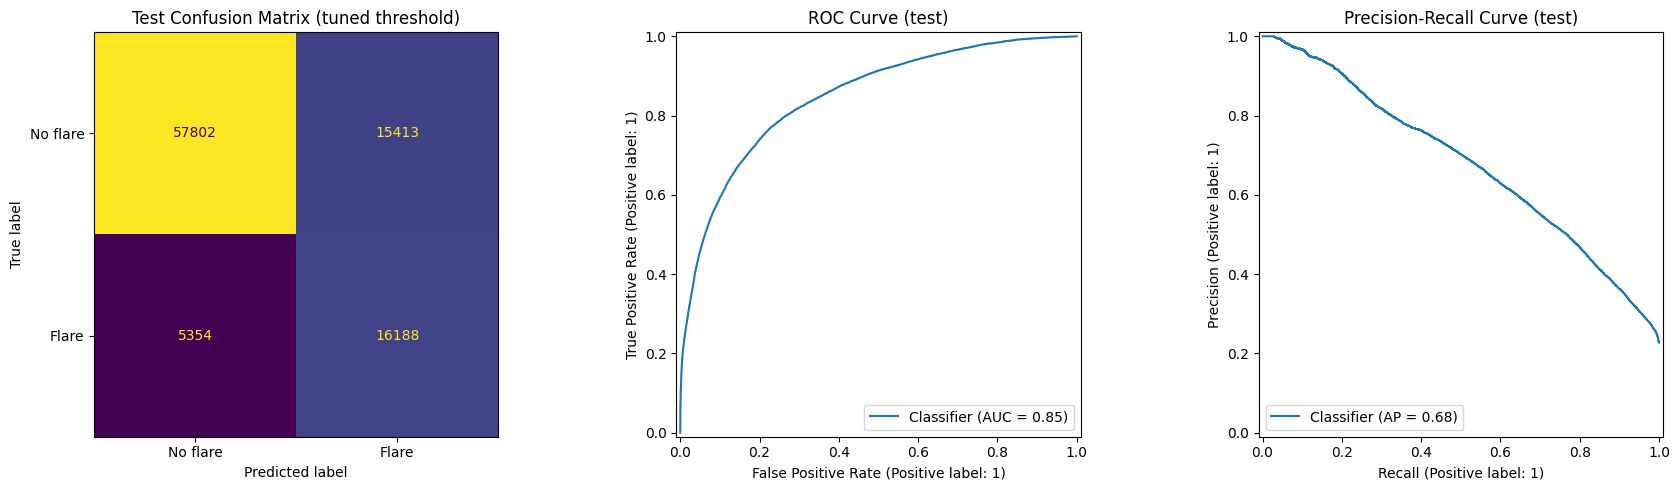

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds_tuned,
    display_labels=["No flare", "Flare"], ax=axes[0], colorbar=False)
axes[0].set_title("Test Confusion Matrix (tuned threshold)")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1])
axes[1].set_title("ROC Curve (test)")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (test)")
plt.tight_layout()
plt.show()

Top magnetic-complexity features driving the SVM decision:

feature_0     3.270221e+00
feature_20   -2.293582e+00
feature_8    -5.257788e-01
feature_21   -4.793324e-01
feature_1     3.731584e-01
feature_22   -3.443468e-01
feature_7     3.439083e-01
feature_23   -2.738606e-01
feature_24   -2.448168e-01
feature_6    -1.506732e-01
feature_28    1.190681e-01
feature_26   -1.110130e-01
feature_9     1.056730e-01
feature_25    1.041666e-01
feature_5     6.048452e-02
feature_4     5.977531e-02
feature_11   -5.414549e-02
feature_12    2.724134e-02
feature_17    2.282902e-02
feature_27   -1.561464e-02
feature_2     1.519923e-02
feature_13    1.514020e-02
feature_15   -1.168520e-02
feature_10   -1.140208e-02
feature_16    7.823472e-03
feature_18    1.766380e-03
feature_19   -1.107877e-03
feature_14   -5.246453e-16
feature_3     0.000000e+00
dtype: float64


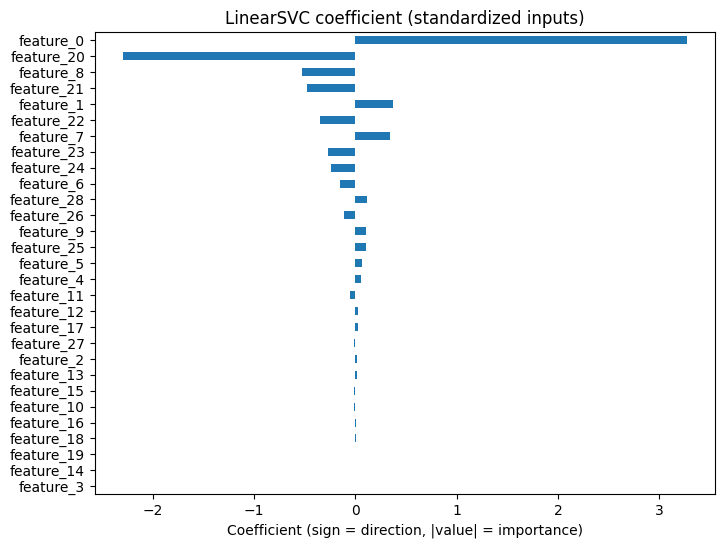

In [17]:
import pandas as pd

coef = svm_model.coef_.ravel()
importance = pd.Series(coef, index=feature_cols).sort_values(key=abs, ascending=False)
print("Top magnetic-complexity features driving the SVM decision:\n")
print(importance)

plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("LinearSVC coefficient (standardized inputs)")
plt.xlabel("Coefficient (sign = direction, |value| = importance)")
plt.gca().invert_yaxis()
plt.show()

In [18]:
rng = np.random.default_rng(42)
n_boot = 1000
# FIX (overfitting / stats): resample by AR, not by row. Rows from the same AR are
# correlated, so row-level bootstrap understates true uncertainty.
test_ar_ids = test_data["AR_number"].values
unique_ars = np.unique(test_ar_ids)
tss_boot = []

codes, uniq = pd.factorize(test_ar_ids); k = len(uniq)
pred_full = (test_scores >= best_thresh).astype(int)
cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                [(y_test == 1) & (pred_full == 1), (y_test == 1) & (pred_full == 0),
                 (y_test == 0) & (pred_full == 1), (y_test == 0) & (pred_full == 0)]], 1)
for _ in range(n_boot):
    tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)   # an AR drawn twice counts twice
    tss_boot.append(tp/(tp+fn) - fp/(fp+tn))

ci_low, ci_high = np.percentile(tss_boot, [2.5, 97.5])
print(f"Test TSS: {tss_tuned:.4f}  (95% bootstrap CI, resampled by AR: [{ci_low:.4f}, {ci_high:.4f}])")


Test TSS: 0.5409  (95% bootstrap CI, resampled by AR: [0.4460, 0.6141])


In [19]:
import joblib
joblib.dump(svm_model, "/kaggle/working/svm_baseline_model.joblib")
joblib.dump(scaler, "/kaggle/working/svm_baseline_scaler.joblib")
joblib.dump({"threshold": best_thresh}, "/kaggle/working/svm_baseline_threshold.joblib")
print("Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib")

Saved: svm_baseline_model.joblib, svm_baseline_scaler.joblib, svm_baseline_threshold.joblib


In [20]:
print(train_data[["feature_3", "feature_14"]].describe())
print("\nUnique values:")
print("feature_3:", train_data["feature_3"].nunique())
print("feature_14:", train_data["feature_14"].nunique())

       feature_3    feature_14
count   759357.0  7.593570e+05
mean         0.0  4.712389e+00
std          0.0  5.398796e-11
min          0.0  4.712389e+00
25%          0.0  4.712389e+00
50%          0.0  4.712389e+00
75%          0.0  4.712389e+00
max          0.0  4.712389e+00

Unique values:
feature_3: 1
feature_14: 1


In [21]:
final_report = f"""
STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)
===============================================

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: {best_thresh:.4f}

TEST SET (final, threshold tuned on val — no test leakage)
TPR: {tpr:.4f}   TNR: {tnr:.4f}
TSS: {tss_tuned:.4f}   (95% bootstrap CI: [{ci_low:.4f}, {ci_high:.4f}])
HSS: {hss_tuned:.4f}

VALIDATION SET
TSS: {best_tss:.4f}

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS {tss_tuned:.4f}, HSS {hss_tuned:.4f} -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)
TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al. 2023 README column order — not yet confirmed)

ARTIFACTS SAVED
/kaggle/working/svm_baseline_model.joblib
/kaggle/working/svm_baseline_scaler.joblib
/kaggle/working/svm_baseline_threshold.joblib

STATUS: Stage 1 complete and locked. Proceeding to Stage 2 (CNN on raw images).
"""
print(final_report)
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)


STAGE 1 — SVM BASELINE: FINAL RESULTS (LOCKED)

METHOD
LinearSVC, class_weight='balanced', StandardScaler fit on train only.
Decision threshold tuned on validation set (maximize TSS), applied unchanged to test.
Chosen threshold: 0.0588

TEST SET (final, threshold tuned on val — no test leakage)
TPR: 0.7515   TNR: 0.7895
TSS: 0.5409   (95% bootstrap CI: [0.4460, 0.6141])
HSS: 0.4644

VALIDATION SET
TSS: 0.5177

BENCHMARK COMPARISON (same dataset, same official AR split)
Boucheron et al. 2023, linear SVM (reduced res): TSS 0.5348, HSS 0.4350
Boucheron et al. 2023, VGG16 frozen transfer:    TSS 0.5325, HSS 0.4636
This baseline: TSS 0.5409, HSS 0.4644 -> reproduces the published SVM; it does not beat it.
(Bloomfield 2012 used a different dataset and method, so it is not a like-for-like comparison.)
TOP DRIVING FEATURES (by |coefficient|)
feature_0, feature_20, feature_8, feature_21, feature_1
(see feature-importance plot; exact physical names require cross-referencing
 the Boucheron et al

In [22]:
final_report += """
DATA QUALITY NOTE
feature_3 and feature_14 are constant across all 759,357 training rows
(feature_3 = 0.0 always; feature_14 = 4.712389 always, std ≈ 5e-11).
These 2 of 29 features carry zero discriminative information in this
preconfigured dataset subset — confirmed via .describe()/.nunique(), not assumed.
"""
with open("/kaggle/working/stage1_final_report.txt", "w") as f:
    f.write(final_report)
print("Updated.")

Updated.


In [23]:
# A1 — configuration, seeds, metrics
import os, re, json, time, random, warnings
import numpy as np, pandas as pd
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score, brier_score_loss)

CFG = dict(
    seed=42,
    hist_lag_h=24,        # flare-history lag. MUST be >= the 24 h label window, otherwise it leaks the future.
    lag_tol_min=30,       # a lag lookup must land within this many minutes of the wanted time (frames have gaps)
    roll_h=2,             # rolling mean/std window (hours)
    kurt_h=(3, 6, 12),    # kurtosis windows (hours)
    diff_h=(1, 3, 6, 12), # "change over the last X hours" lags
    top_k=10,             # how many base features get the temporal treatment (chosen by importance, TRAIN only)
    const_cols=("feature_3", "feature_14"),   # constant in this dataset (your cell 19)
)

def set_all_seeds(seed=CFG["seed"]):
    random.seed(seed); np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
set_all_seeds()

def skill_scores(y, pred):
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    d = lambda a, b: a / b if b else np.nan
    tpr, fpr = d(tp, tp + fn), d(fp, fp + tn)
    den = (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)
    return dict(TSS=tpr - fpr, HSS=d(2 * (tp * tn - fn * fp), den), POD=tpr, FPR=fpr,
                FAR=d(fp, tp + fp), CSI=d(tp, tp + fn + fp), TP=tp, FP=fp, FN=fn, TN=tn)

def best_tss_threshold(y, score):
    """Exact TSS-optimal threshold (TSS = TPR - FPR). Fit on VALIDATION only, then freeze."""
    fpr, tpr, thr = roc_curve(y, score)
    return float(thr[np.argmax(tpr - fpr)])

def prob_scores(y, p):
    bs = brier_score_loss(y, p)
    bs_ref = brier_score_loss(y, np.full(len(y), np.mean(y)))   # climatology reference
    return dict(ROC_AUC=roc_auc_score(y, p), PR_AUC=average_precision_score(y, p), Brier=bs, BSS=1 - bs / bs_ref)

def full_report(y, p, thr):
    return {**prob_scores(y, p), **skill_scores(y, (np.asarray(p) >= thr).astype(int))}

def ar_bootstrap(ar_ids, y, pred, n_boot=2000, seed=CFG["seed"]):
    """95% CI of TSS by resampling whole active regions (per-AR confusion counts -> fast)."""
    codes, _ = pd.factorize(np.asarray(ar_ids)); k = codes.max() + 1
    y, pred = np.asarray(y), np.asarray(pred)
    cnt = np.stack([np.bincount(codes, weights=m.astype(float), minlength=k) for m in
                    [(y == 1) & (pred == 1), (y == 1) & (pred == 0), (y == 0) & (pred == 1), (y == 0) & (pred == 0)]], 1)
    rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        tp, fn, fp, tn = cnt[rng.integers(0, k, k)].sum(0)
        out.append(tp / (tp + fn) - fp / (fp + tn))
    return np.percentile(out, [2.5, 97.5])
print("A1 ready.")

A1 ready.


In [24]:
# A2 — full-series table (uses df, train_ar, val_ar, test_ar from your cells 0 and 6)
base_cols = [f"feature_{i}" for i in range(29) if f"feature_{i}" not in CFG["const_cols"]]

def flare_score(s):
    """'C4.7' -> 47, 'M1.2' -> 120, 'X2.0' -> 2000 (weighting idea from Williams et al. 2026); no flare -> 0."""
    s = str(s).strip()
    if s in ("0", "0.0", "nan", "None", ""): return 0.0
    mult = {"C": 10.0, "M": 100.0, "X": 1000.0}.get(s[0].upper())
    try: return mult * float(s[1:]) if mult else 0.0
    except ValueError: return 0.0

T = df.copy()
T["AR"] = T["filename"].str.split("_").str[0]
T["ts"] = pd.to_datetime(T["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S")
tr_ids, va_ids, te_ids = (set(map(str, s)) for s in (train_ar, val_ar, test_ar))
T["split"] = np.select([T.AR.isin(tr_ids), T.AR.isin(va_ids), T.AR.isin(te_ids)], ["train", "val", "test"], default="none")
assert (T.split == "none").sum() == 0, "some rows belong to no split"
fs_map = {s: flare_score(s) for s in T["flare_size"].astype(str).unique()}
T["fscore"] = T["flare_size"].astype(str).map(fs_map)
T = T.sort_values(["AR", "ts"]).reset_index(drop=True)
print(T.split.value_counts().to_dict(), "| ARs:", T.AR.nunique(), "| positives:", int(T.label.sum()))

{'train': 759357, 'val': 95933, 'test': 94757} | ARs: 1570 | positives: 190582


In [25]:
# T1 — config + raw-order monotonicity check (uses the ORIGINAL df, before our own sorting,
# so this checks whether the SOURCE FILES themselves are already time-ordered)
TOL_S = 60          # tolerance band around the 720s nominal cadence, in seconds
CADENCE_S = 720

raw_ts = pd.to_datetime(df["filename"].str.extract(r"(\d{8}_\d{6})")[0], format="%Y%m%d_%H%M%S", errors="coerce")
n_unparseable_total = int(raw_ts.isna().sum())

def _nonmono_count(g):
    t = g.to_numpy()
    ok = ~pd.isna(t)
    t = t[ok]
    if len(t) < 2:
        return 0
    return int((np.diff(t.astype("datetime64[s]").astype(np.int64)) < 0).sum())

nonmono_by_ar = raw_ts.groupby(df["AR_number"]).apply(_nonmono_count)
print(f"Unparseable timestamps in the whole dataset: {n_unparseable_total}")
print(f"ARs whose rows are NOT already time-ordered in the CSV: {(nonmono_by_ar > 0).sum()} / {df['AR_number'].nunique()}")
print(f"Total out-of-order adjacent pairs (raw file order): {int(nonmono_by_ar.sum())}")

Unparseable timestamps in the whole dataset: 0
ARs whose rows are NOT already time-ordered in the CSV: 0 / 1570
Total out-of-order adjacent pairs (raw file order): 0


In [26]:
# T2 — per-AR temporal summary (built on T, which is already parsed, time-sorted and
# split-labelled by your own cell A2 — no re-parsing, no re-splitting)
ar_ids   = T["AR"].to_numpy()
ts_s     = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
lab_arr  = T["label"].to_numpy()
bounds   = np.flatnonzero(np.r_[True, ar_ids[1:] != ar_ids[:-1], True])   # same AR-block pattern as your A4/A6

rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    n = b - a
    rec = dict(
        AR_number=ar_ids[a], n_observations=int(n),
        first_timestamp=pd.Timestamp(t[0], unit="s"), last_timestamp=pd.Timestamp(t[-1], unit="s"),
        duration_hours=(t[-1] - t[0]) / 3600.0,
    )
    if n >= 2:
        d = np.diff(t).astype(float)
        rec.update(
            median_delta_seconds=float(np.median(d)), mean_delta_seconds=float(np.mean(d)),
            min_delta_seconds=float(d.min()), max_delta_seconds=float(d.max()), std_delta_seconds=float(np.std(d)),
            n_duplicate_timestamps=int((d == 0).sum()),
            n_short_intervals=int(((d < CADENCE_S - TOL_S) & (d > 0)).sum()),
        )
        gaps = d[d > CADENCE_S + TOL_S]
        rec["n_large_gaps"] = int(len(gaps))
        missing = np.round(gaps / CADENCE_S) - 1
        rec["n_missing_intervals"] = int(missing[missing > 0].sum())
        rec["n_irregular_gaps"] = int((np.abs(gaps - np.round(gaps / CADENCE_S) * CADENCE_S) > TOL_S).sum())
    else:
        rec.update(median_delta_seconds=np.nan, mean_delta_seconds=np.nan, min_delta_seconds=np.nan,
                    max_delta_seconds=np.nan, std_delta_seconds=np.nan, n_duplicate_timestamps=0,
                    n_short_intervals=0, n_large_gaps=0, n_missing_intervals=0, n_irregular_gaps=0)
    rows.append(rec)

ar_temporal_summary = pd.DataFrame(rows)
ar_temporal_summary["sequence_length"] = ar_temporal_summary["n_observations"]
ar_temporal_summary["n_non_monotonic"] = ar_temporal_summary["AR_number"].map(nonmono_by_ar).fillna(0).astype(int)
ar_temporal_summary["n_unparseable_timestamps"] = (
    raw_ts.isna().groupby(df["AR_number"]).sum().reindex(ar_temporal_summary["AR_number"]).fillna(0).to_numpy().astype(int)
)
print("ar_temporal_summary:", ar_temporal_summary.shape)
display(ar_temporal_summary.head())

desc_cols = ["n_observations", "duration_hours", "median_delta_seconds", "mean_delta_seconds",
             "min_delta_seconds", "max_delta_seconds", "std_delta_seconds",
             "n_large_gaps", "n_missing_intervals", "n_duplicate_timestamps", "n_non_monotonic"]
display(ar_temporal_summary[desc_cols].describe(percentiles=[.25, .5, .75]).round(3))

ar_temporal_summary: (1570, 18)


,AR_number,n_observations,first_timestamp,last_timestamp,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_duplicate_timestamps,n_short_intervals,n_large_gaps,n_missing_intervals,n_irregular_gaps,sequence_length,n_non_monotonic,n_unparseable_timestamps
0,1064,358,2010-05-01 00:00:00,2010-05-03 23:48:00,71.8,720.0,724.033613,720.0,2160.0,76.106066,0,0,1,2,0,358,0,0
1,1065,240,2010-05-03 00:00:00,2010-05-04 23:48:00,47.8,720.0,720.000000,720.0,720.0,0.000000,0,0,0,0,0,240,0,0
2,1066,478,2010-05-03 00:00:00,2010-05-06 23:48:00,95.8,720.0,723.018868,720.0,2160.0,65.863922,0,0,1,2,0,478,0,0
3,1067,522,2010-05-03 15:12:00,2010-05-07 23:48:00,104.6,720.0,722.763916,720.0,2160.0,63.026972,0,0,1,2,0,522,0,0
4,1068,348,2010-05-06 02:00:00,2010-05-08 23:48:00,69.8,720.0,724.149856,720.0,2160.0,77.191782,0,0,1,2,0,348,0,0


,n_observations,duration_hours,median_delta_seconds,mean_delta_seconds,min_delta_seconds,max_delta_seconds,std_delta_seconds,n_large_gaps,n_missing_intervals,n_duplicate_timestamps,n_non_monotonic
count,1570.000,1570.000,1570.0,1570.000,1570.0,1570.000,1570.000,1570.000,1570.000,1570.0,1570.0
mean,605.125,123.429,720.0,736.465,720.0,5453.197,239.697,2.126,13.017,0.0,0.0
std,316.406,64.466,0.0,28.935,0.0,7470.924,357.230,3.472,20.450,0.0,0.0
min,3.000,0.400,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
25%,335.250,71.650,720.0,720.000,720.0,720.000,0.000,0.000,0.000,0.0,0.0
50%,633.500,130.100,720.0,723.019,720.0,2160.000,68.684,1.000,2.000,0.0,0.0
75%,915.000,187.400,720.0,744.235,720.0,7200.000,476.505,2.000,22.000,0.0,0.0
max,1080.000,215.800,720.0,1173.699,720.0,56160.000,3849.761,30.000,131.000,0.0,0.0


In [27]:
# T3 — cadence classification: what fraction of intervals are exact / approx / gap / short / duplicate
all_deltas = []
for a, b in zip(bounds[:-1], bounds[1:]):
    t = ts_s[a:b]
    if b - a >= 2:
        all_deltas.append(np.diff(t).astype(float))
all_deltas = np.concatenate(all_deltas) if all_deltas else np.array([])

exact   = (all_deltas == CADENCE_S)
approx  = (~exact) & (np.abs(all_deltas - CADENCE_S) <= TOL_S)
gap     = all_deltas > CADENCE_S + TOL_S
short   = (all_deltas > 0) & (all_deltas < CADENCE_S - TOL_S)
dup     = all_deltas == 0

print(f"Total intervals analysed: {len(all_deltas):,}")
for name, mask in [("exactly 720s", exact), (f"approx 720s (+/-{TOL_S}s)", approx),
                    ("> 720s (gap)", gap), ("< 720s (short, not duplicate)", short), ("duplicate (0s)", dup)]:
    print(f"  {name:32s} {mask.sum():>9,}  ({100*mask.mean():5.2f}%)")

def ar_bucket(row):
    if row["n_observations"] < 2: return "single-obs (n/a)"
    if row["n_large_gaps"] == 0 and row["n_duplicate_timestamps"] == 0 and row["n_short_intervals"] == 0:
        return "perfect/near-perfect cadence"
    if row["n_large_gaps"] <= 2:
        return "small deviations"
    return "significant gaps"
ar_temporal_summary["cadence_bucket"] = ar_temporal_summary.apply(ar_bucket, axis=1)
bucket_pct = (ar_temporal_summary["cadence_bucket"].value_counts(normalize=True) * 100).round(2)
print("\nPer-AR cadence quality:"); print(bucket_pct)

Total intervals analysed: 948,477
  exactly 720s                       945,139  (99.65%)
  approx 720s (+/-60s)                     0  ( 0.00%)
  > 720s (gap)                         3,338  ( 0.35%)
  < 720s (short, not duplicate)            0  ( 0.00%)
  duplicate (0s)                           0  ( 0.00%)

Per-AR cadence quality:
cadence_bucket
small deviations                42.93
perfect/near-perfect cadence    34.46
significant gaps                22.61
Name: proportion, dtype: float64


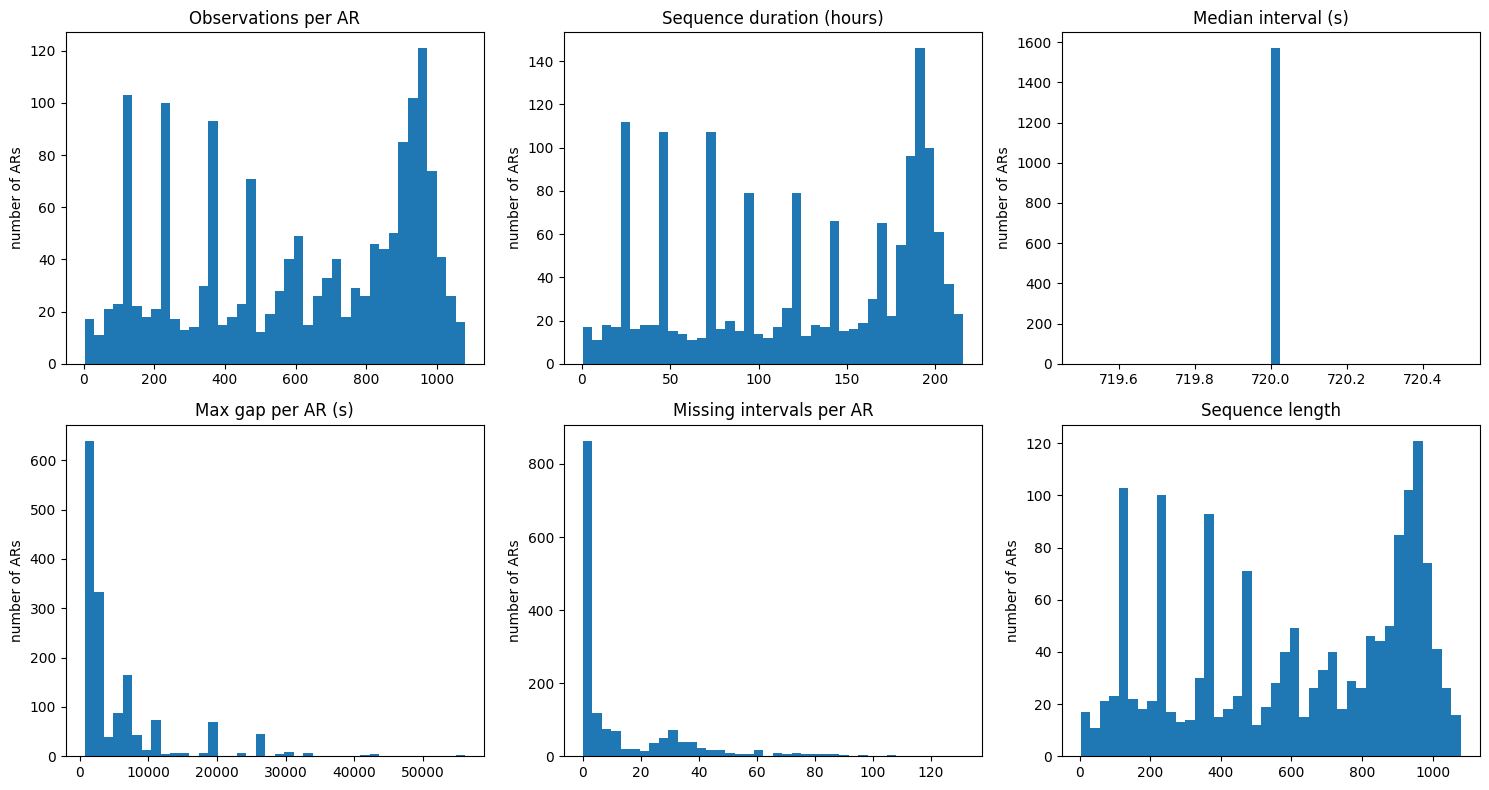

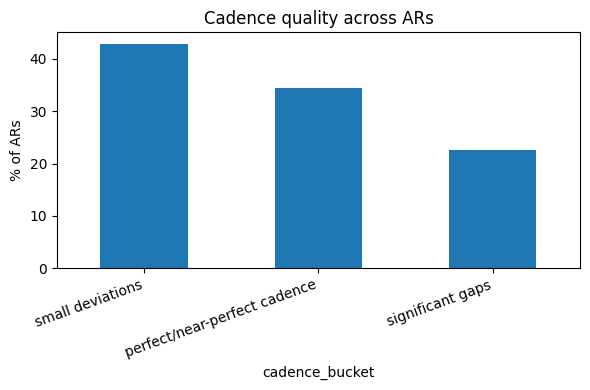

In [28]:
# T4 — plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0,0].hist(ar_temporal_summary["n_observations"], bins=40); axes[0,0].set_title("Observations per AR")
axes[0,1].hist(ar_temporal_summary["duration_hours"], bins=40); axes[0,1].set_title("Sequence duration (hours)")
axes[0,2].hist(ar_temporal_summary["median_delta_seconds"].dropna(), bins=40); axes[0,2].set_title("Median interval (s)")
axes[1,0].hist(ar_temporal_summary["max_delta_seconds"].dropna(), bins=40); axes[1,0].set_title("Max gap per AR (s)")
axes[1,1].hist(ar_temporal_summary["n_missing_intervals"], bins=40); axes[1,1].set_title("Missing intervals per AR")
axes[1,2].hist(ar_temporal_summary["sequence_length"], bins=40); axes[1,2].set_title("Sequence length")
for ax in axes.flat: ax.set_ylabel("number of ARs")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
bucket_pct.plot(kind="bar")
plt.title("Cadence quality across ARs"); plt.ylabel("% of ARs"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

ARs with only label 0:            936
ARs with at least one label 1:    634
ARs with both 0 and 1:            614

Positive-run length (consecutive positive frames within an AR), across ARs that have any:
count     634.00
mean      212.41
std       182.88
min         6.00
25%       119.25
50%       131.00
75%       250.50
max      1013.00
Name: max_pos_run, dtype: float64

Hours between the LAST positive frame and the end of that AR's sequence:
count    634.00
mean      46.59
std       54.17
min        0.00
25%        0.00
50%       24.80
75%       78.40
max      207.80
Name: hours_last_positive_to_seq_end, dtype: float64


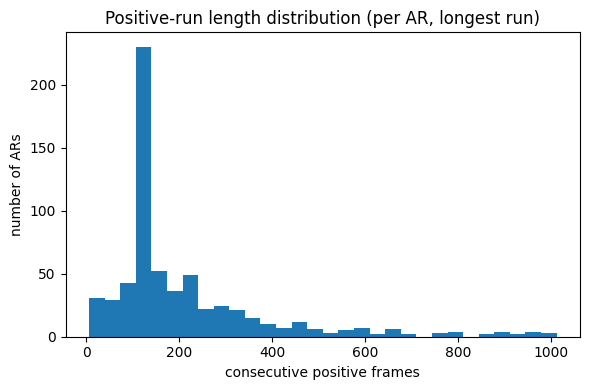

In [29]:
# T5 — label run-length analysis per AR (0-runs and 1-runs, transitions, and where
# positives sit relative to the end of the sequence)
run_rows = []
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b].astype(int)
    t = ts_s[a:b]
    n = len(lab)
    change = np.flatnonzero(np.r_[True, lab[1:] != lab[:-1], True])
    run_vals = lab[change[:-1]]; run_lens = np.diff(change)
    pos_lens = run_lens[run_vals == 1]
    trans_01 = int(((lab[:-1] == 0) & (lab[1:] == 1)).sum()) if n > 1 else 0
    trans_10 = int(((lab[:-1] == 1) & (lab[1:] == 0)).sum()) if n > 1 else 0
    has_pos = bool((lab == 1).any())
    pos_idx = np.flatnonzero(lab == 1)
    rec = dict(
        AR_number=ar_ids[a], n_observations=n,
        all_zero=bool((lab == 0).all()), has_positive=has_pos, has_both=has_pos and (lab == 0).any(),
        n_pos_runs=int(len(pos_lens)), max_pos_run=int(pos_lens.max()) if len(pos_lens) else 0,
        median_pos_run=float(np.median(pos_lens)) if len(pos_lens) else np.nan,
        n_transitions_0to1=trans_01, n_transitions_1to0=trans_10, n_transitions_total=trans_01 + trans_10,
        first_positive_timestamp=pd.Timestamp(t[pos_idx[0]], unit="s") if has_pos else pd.NaT,
        last_positive_timestamp=pd.Timestamp(t[pos_idx[-1]], unit="s") if has_pos else pd.NaT,
        hours_last_positive_to_seq_end=(t[-1] - t[pos_idx[-1]]) / 3600.0 if has_pos else np.nan,
    )
    run_rows.append(rec)
ar_label_run_summary = pd.DataFrame(run_rows)

n_all_zero = int(ar_label_run_summary["all_zero"].sum())
n_has_pos  = int(ar_label_run_summary["has_positive"].sum())
n_both     = int(ar_label_run_summary["has_both"].sum())
print(f"ARs with only label 0:            {n_all_zero}")
print(f"ARs with at least one label 1:    {n_has_pos}")
print(f"ARs with both 0 and 1:            {n_both}")

pos_only = ar_label_run_summary[ar_label_run_summary.has_positive]
print("\nPositive-run length (consecutive positive frames within an AR), across ARs that have any:")
print(pos_only["max_pos_run"].describe().round(2))
print("\nHours between the LAST positive frame and the end of that AR's sequence:")
print(pos_only["hours_last_positive_to_seq_end"].describe().round(2))

plt.figure(figsize=(6,4))
pos_only["max_pos_run"].plot(kind="hist", bins=30)
plt.title("Positive-run length distribution (per AR, longest run)"); plt.xlabel("consecutive positive frames"); plt.ylabel("number of ARs")
plt.tight_layout(); plt.show()

In [30]:
# T6 — quantifying window overlap between adjacent samples
overlap_hours = 24.0
nominal_overlap_pct = 100 * (overlap_hours - CADENCE_S/3600) / overlap_hours
print(f"At the nominal {CADENCE_S}s cadence, two consecutive frames' 24h windows overlap by "
      f"{overlap_hours - CADENCE_S/3600:.3f} of 24 h -> {nominal_overlap_pct:.2f}% overlap.")

same_label_count, total_pairs = 0, 0
for a, b in zip(bounds[:-1], bounds[1:]):
    lab = lab_arr[a:b]
    if len(lab) > 1:
        same_label_count += int((lab[1:] == lab[:-1]).sum())
        total_pairs += len(lab) - 1
print(f"Empirically, adjacent frames share the same label in {100*same_label_count/total_pairs:.2f}% of "
      f"{total_pairs:,} consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class "
      "imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.")

print("""
WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY ITSELF, MEAN LEAKAGE
  Leakage means the model gets information it shouldn't have at prediction time. Overlapping labels are a
  property of the forecasting TASK's definition (rolling 24h window), not a broken pipeline. As long as
  (a) the label was computed only from GOES data strictly AFTER the image time, and (b) splits are AR-level,
  the overlap is expected and correct -- it means consecutive frames are correlated, which is a modeling and
  evaluation consideration, not a leakage bug.
""")

At the nominal 720s cadence, two consecutive frames' 24h windows overlap by 23.800 of 24 h -> 99.17% overlap.
Empirically, adjacent frames share the same label in 99.81% of 948,477 consecutive pairs (whole-dataset average) -- this also reflects the 80/20 class imbalance, not overlap alone, so treat it as supporting evidence, not proof by itself.

WHY THIS HAPPENS
  label(t) = 1 means "a flare occurs somewhere in [t, t+24h]". Because t+12min is inside [t, t+24h] for
  almost its whole length, frame t and frame t+12min are asking about nearly the SAME future window, so
  they usually get the same answer. A long run of 1s does NOT mean many separate flares -- it usually
  means one flare (or cluster) is visible through many overlapping 24h windows.

WHY THIS MATTERS FOR MODELING
  Rows within an AR are NOT independent samples. This is exactly why your official split is AR-level, and
  why your AR-bootstrap (not a per-row bootstrap) is used for confidence intervals.

WHY THIS DOES NOT, BY 

In [31]:
# T7 — split conformity re-check (read-only) + the 3 kinds of leakage, explained
split_per_ar = T.groupby("AR")["split"].nunique()
print("ARs that appear under more than one split label:", int((split_per_ar > 1).sum()),
      "(should be 0 -- this only re-confirms cell A2's own split, nothing is changed)")

print("""
A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.
""")

ARs that appear under more than one split label: 0 (should be 0 -- this only re-confirms cell A2's own split, nothing is changed)

A. AR-LEVEL LEAKAGE: the same AR appears in more than one split. Already checked in your cell 4; re-confirmed above.
B. TEMPORAL LEAKAGE: a feature at time t uses information from AFTER t. Your A6 leakage canary demonstrates
   this concretely -- a 12h-lag "history" feature (which still reaches into the future, since the label
   itself covers [t, t+24h]) inflates validation TSS above the honest 24h-lag version.
C. LABEL LEAKAGE: a feature is mathematically derived from the target itself.
   These are independent checks -- passing one does not guarantee the others.



In [32]:
# T8 — data-quality flag table (flags only, deletes nothing)
q = ar_temporal_summary.merge(ar_label_run_summary[["AR_number","has_positive"]], on="AR_number")
q["flag_large_gap"]     = q["max_delta_seconds"] > 3 * CADENCE_S
q["flag_many_missing"]  = q["n_missing_intervals"] >= 3
q["flag_duplicates"]    = q["n_duplicate_timestamps"] > 0
q["flag_short_seq"]     = q["n_observations"] < 10
q["flag_nonmonotonic"]  = q["n_non_monotonic"] > 0
q["flag_unparseable"]   = q["n_unparseable_timestamps"] > 0
flag_cols = [c for c in q.columns if c.startswith("flag_")]
q["n_flags"] = q[flag_cols].sum(axis=1)

problem_ars = q[q["n_flags"] > 0].sort_values(["n_flags", "max_delta_seconds"], ascending=[False, False])
print(f"ARs with at least one data-quality flag: {len(problem_ars)} / {len(q)}")
display(problem_ars[["AR_number","n_observations","max_delta_seconds","n_missing_intervals",
                      "n_duplicate_timestamps","n_non_monotonic","n_unparseable_timestamps","n_flags"]].head(20))

ARs with at least one data-quality flag: 785 / 1570


,AR_number,n_observations,max_delta_seconds,n_missing_intervals,n_duplicate_timestamps,n_non_monotonic,n_unparseable_timestamps,n_flags
615,1727,747,56160.0,81,0,0,0,2
617,1729,353,56160.0,80,0,0,0,2
1563,2725,387,43920.0,68,0,0,0,2
216,1301,847,42480.0,131,0,0,0,2
217,1302,911,42480.0,122,0,0,0,2
218,1304,598,42480.0,106,0,0,0,2
219,1305,898,42480.0,111,0,0,0,2
1170,2313,781,41040.0,59,0,0,0,2
1173,2316,424,41040.0,56,0,0,0,2
22,1087,871,33840.0,106,0,0,0,2


In [33]:
# T9 — final report: compile, print, save
pct_perfect = bucket_pct.get("perfect/near-perfect cadence", 0.0)
report_temporal = f"""
TEMPORAL INTEGRITY REPORT
==========================
Tolerance used for "approximately 720s": +/-{TOL_S}s.

1. Total ARs: {T['AR'].nunique()}
2. Total observations: {len(T):,}
3. Median observations per AR: {ar_temporal_summary['n_observations'].median():.0f}
4. Median sequence duration (hours): {ar_temporal_summary['duration_hours'].median():.2f}
5. Median cadence (seconds): {ar_temporal_summary['median_delta_seconds'].median():.1f}
6. ARs with perfect/near-perfect cadence: {pct_perfect:.2f}%
7. ARs with >=1 missing interval: {(ar_temporal_summary['n_missing_intervals']>0).sum()}
8. ARs with >=1 duplicate timestamp: {(ar_temporal_summary['n_duplicate_timestamps']>0).sum()}
9. ARs with >=1 non-monotonic raw-order pair: {(ar_temporal_summary['n_non_monotonic']>0).sum()}
10. ARs containing positive labels: {n_has_pos}
11. ARs containing both 0 and 1: {n_both}
12. Median positive-run length (ARs w/ >=1): {pos_only['max_pos_run'].median():.2f}
13. Maximum positive-run length (any AR): {int(pos_only['max_pos_run'].max()) if len(pos_only) else 0}
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model
"""
print(report_temporal)
ar_temporal_summary.to_csv("/kaggle/working/ar_temporal_summary.csv", index=False)
ar_label_run_summary.to_csv("/kaggle/working/ar_label_run_summary.csv", index=False)
with open("/kaggle/working/temporal_integrity_report.txt", "w") as f:
    f.write(report_temporal)
print("Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt")


TEMPORAL INTEGRITY REPORT
Tolerance used for "approximately 720s": +/-60s.

1. Total ARs: 1570
2. Total observations: 950,047
3. Median observations per AR: 634
4. Median sequence duration (hours): 130.10
5. Median cadence (seconds): 720.0
6. ARs with perfect/near-perfect cadence: 34.46%
7. ARs with >=1 missing interval: 1029
8. ARs with >=1 duplicate timestamp: 0
9. ARs with >=1 non-monotonic raw-order pair: 0
10. ARs containing positive labels: 634
11. ARs containing both 0 and 1: 614
12. Median positive-run length (ARs w/ >=1): 131.00
13. Maximum positive-run length (any AR): 1013
14. CONCERNS BEFORE CNN+GRU/LSTM:
    - Handle gaps explicitly (pad/mask by real timestamp, not row position)
    - Treat consecutive frames as correlated, not independent
    - Review flagged ARs above before they enter a sequence model

Saved: ar_temporal_summary.csv, ar_label_run_summary.csv, temporal_integrity_report.txt


In [34]:
# --- Check 2: worst gap, using T's real columns (AR, ts) ---
T = T.sort_values(["AR", "ts"]).reset_index(drop=True)
T["delta_seconds"] = T.groupby("AR")["ts"].diff().dt.total_seconds()

worst_gap = T["delta_seconds"].max()
worst_rows = T[T["delta_seconds"] == worst_gap]
print("Max gap (s):", worst_gap)
print(worst_rows[["AR", "ts", "delta_seconds", "label", "filename"]])

for ar in worst_rows["AR"].unique():
    sub = T[T["AR"] == ar].reset_index(drop=True)
    idx = sub.index[sub["delta_seconds"] == worst_gap][0]
    display(sub.loc[max(0, idx-2):idx+2, ["AR", "ts", "delta_seconds", "label", "flare_size", "filename"]])

Max gap (s): 56160.0
          AR                  ts  delta_seconds  label  \
369081  1727 2013-04-24 19:12:00        56160.0      0   
370330  1729 2013-04-24 19:12:00        56160.0      0   

                                                 filename  
369081  1727_hmi.M_720s.20130424_191200_TAI.1.magnetog...  
370330  1729_hmi.M_720s.20130424_191200_TAI.1.magnetog...  


,AR,ts,delta_seconds,label,flare_size,filename
401,1727,2013-04-24 03:24:00,720.0,0,0,1727_hmi.M_720s.20130424_032400_TAI.1.magnetog...
402,1727,2013-04-24 03:36:00,720.0,0,0,1727_hmi.M_720s.20130424_033600_TAI.1.magnetog...
403,1727,2013-04-24 19:12:00,56160.0,0,0,1727_hmi.M_720s.20130424_191200_TAI.1.magnetog...
404,1727,2013-04-24 19:24:00,720.0,0,0,1727_hmi.M_720s.20130424_192400_TAI.1.magnetog...
405,1727,2013-04-24 19:36:00,720.0,0,0,1727_hmi.M_720s.20130424_193600_TAI.1.magnetog...


,AR,ts,delta_seconds,label,flare_size,filename
17,1729,2013-04-24 03:24:00,720.0,0,0,1729_hmi.M_720s.20130424_032400_TAI.1.magnetog...
18,1729,2013-04-24 03:36:00,720.0,0,0,1729_hmi.M_720s.20130424_033600_TAI.1.magnetog...
19,1729,2013-04-24 19:12:00,56160.0,0,0,1729_hmi.M_720s.20130424_191200_TAI.1.magnetog...
20,1729,2013-04-24 19:24:00,720.0,0,0,1729_hmi.M_720s.20130424_192400_TAI.1.magnetog...
21,1729,2013-04-24 19:36:00,720.0,0,0,1729_hmi.M_720s.20130424_193600_TAI.1.magnetog...


In [35]:
# --- Check 3: longest positive run, using T's real columns ---
T["run_id"] = (T["label"] != T.groupby("AR")["label"].shift()).cumsum()
runs = T[T["label"] == 1].groupby("run_id").agg(
    AR=("AR", "first"), start_ts=("ts", "first"), end_ts=("ts", "last"), n_frames=("ts", "size")
)
longest = runs.sort_values("n_frames", ascending=False).head(1)
display(longest)

ar_ = longest["AR"].iloc[0]
start_, end_ = longest["start_ts"].iloc[0], longest["end_ts"].iloc[0]
seg = T[(T["AR"] == ar_) & (T["ts"] >= start_) & (T["ts"] <= end_)]
display(seg[["AR", "ts", "delta_seconds", "label", "flare_size"]])
print("Duration:", (end_ - start_).total_seconds()/3600, "hours")

,AR,start_ts,end_ts,n_frames
run_id,,,,
1794,1967,2014-01-30,2014-02-07 13:48:00,1013


,AR,ts,delta_seconds,label,flare_size
504154,1967,2014-01-30 00:00:00,NaN,1,M6.6
504155,1967,2014-01-30 00:12:00,720.0,1,M6.6
504156,1967,2014-01-30 00:24:00,720.0,1,M6.6
504157,1967,2014-01-30 00:36:00,720.0,1,M6.6
504158,1967,2014-01-30 00:48:00,720.0,1,M6.6
...,...,...,...,...,...
505162,1967,2014-02-07 13:00:00,720.0,1,C3.2
505163,1967,2014-02-07 13:12:00,720.0,1,C3.2
505164,1967,2014-02-07 13:24:00,720.0,1,C3.2
505165,1967,2014-02-07 13:36:00,720.0,1,C3.2


Duration: 205.8 hours


In [36]:
# A3 — XGBoost baseline "A" on the 29 raw features (minus the 2 constants)
import xgboost as xgb

XGB_PARAMS = dict(
    n_estimators=3000, learning_rate=0.05, max_depth=5,
    min_child_weight=60,            # large leaves: frames from one AR are near-duplicates, so don't let trees memorise them
    subsample=0.5, colsample_bytree=0.6, reg_lambda=10.0,
    tree_method="hist", eval_metric="aucpr", early_stopping_rounds=60,
    random_state=CFG["seed"], n_jobs=-1,
)
# NOTE: no scale_pos_weight on purpose -> probabilities stay closer to calibrated; the threshold handles imbalance.
try:                                   # use the GPU automatically if the notebook has one
    import torch
    XGB_PARAMS["device"] = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    XGB_PARAMS["device"] = "cpu"
print("XGBoost device:", XGB_PARAMS["device"])

def fit_gbdt(Xtr, ytr, Xva, yva, params=XGB_PARAMS):
    m = xgb.XGBClassifier(**params)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

y_all = T["label"].to_numpy().astype(int)
M_tr, M_va, M_te = [(T.split == s).to_numpy() for s in ("train", "val", "test")]
ar_all = T["AR"].to_numpy()

XA = T[base_cols].astype(np.float32)
t0 = time.time()
mA = fit_gbdt(XA[M_tr], y_all[M_tr], XA[M_va], y_all[M_va])
pA_va = mA.predict_proba(XA[M_va])[:, 1]
thrA = best_tss_threshold(y_all[M_va], pA_va)
repA = full_report(y_all[M_va], pA_va, thrA)
print(f"[A raw-29] best_iter={mA.best_iteration}  {time.time()-t0:.0f}s")
print({k: round(float(v), 4) for k, v in repA.items() if k in ("ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS")})

# which base features deserve the temporal treatment (importance measured on the TRAIN-fitted model only)
imp = pd.Series(mA.get_booster().get_score(importance_type="gain")).reindex(base_cols).fillna(0).sort_values(ascending=False)
top_names = list(imp.index[:CFG["top_k"]])
print("Top features for temporal treatment:", top_names)

XGBoost device: cuda
[A raw-29] best_iter=151  4s
{'ROC_AUC': 0.8363, 'PR_AUC': 0.6236, 'BSS': 0.2885, 'TSS': 0.5136, 'HSS': 0.4366}
Top features for temporal treatment: ['feature_1', 'feature_22', 'feature_0', 'feature_28', 'feature_4', 'feature_8', 'feature_10', 'feature_25', 'feature_21', 'feature_13']


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:28:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [37]:
# A4 — temporal features (past-only) computed on the FULL 12-min series
def slog(x): return np.sign(x) * np.log1p(np.abs(x))

Z_all = slog(T[base_cols].to_numpy(np.float64))
mu, sd = Z_all[M_tr].mean(0), Z_all[M_tr].std(0) + 1e-9        # statistics from TRAIN rows only
Z = (Z_all - mu) / sd

def _csum(a): return np.concatenate([[0.0], np.cumsum(a)])

def roll_stats(x, start, want_kurt=False):
    """mean, std (and excess kurtosis) over the window [start[i] .. i], i.e. past + current frame only."""
    idx = np.arange(len(x)); n = (idx + 1 - start).astype(float)
    c1, c2 = _csum(x), _csum(x ** 2)
    s1, s2 = c1[idx + 1] - c1[start], c2[idx + 1] - c2[start]
    m = s1 / n; var = np.maximum(s2 / n - m ** 2, 0.0)
    res = [m, np.sqrt(var)]
    if want_kurt:
        c3, c4 = _csum(x ** 3), _csum(x ** 4)
        s3, s4 = c3[idx + 1] - c3[start], c4[idx + 1] - c4[start]
        m4 = (s4 - 4 * m * s3 + 6 * m ** 2 * s2 - 4 * m ** 3 * s1 + n * m ** 4) / n
        with np.errstate(divide="ignore", invalid="ignore"):
            k = m4 / var ** 2 - 3.0
        k[(n < 8) | (var < 1e-8)] = np.nan
        res.append(k)
    return res

def lag_index(t, lag_s, tol_s):
    """Index of the last frame with time <= t - lag (and within tol of it); -1 if none."""
    j = np.searchsorted(t, t - lag_s, side="right") - 1
    ok = j >= 0
    ok[ok] = t[j[ok]] >= (t[ok] - lag_s - tol_s)
    return np.where(ok, j, -1)

def build_features(T, Z, top_idx, names, cfg=CFG):
    n = len(T)
    ts = T["ts"].to_numpy("datetime64[s]").astype(np.int64)
    ar = T["AR"].to_numpy()
    lab = T["label"].to_numpy(np.float64); fsc = T["fscore"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    tol = cfg["lag_tol_min"] * 60; H = int(cfg["hist_lag_h"] * 3600)
    cols = {}
    def alloc(k): cols[k] = np.full(n, np.nan, np.float32)
    for c in names:
        alloc(f"{c}_m{cfg['roll_h']}h"); alloc(f"{c}_s{cfg['roll_h']}h")
        for kh in cfg["kurt_h"]: alloc(f"{c}_k{kh}h")
        for dh in cfg["diff_h"]: alloc(f"{c}_d{dh}h")
    for k in ("age_h", "hist24_flag", "hist24_score"): alloc(k)
    hist_src = np.full(n, -1, np.int64)
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts[a:b]
        starts = {h: np.searchsorted(t, t - int(h * 3600), side="left") for h in {cfg["roll_h"], *cfg["kurt_h"]}}
        lags = {h: lag_index(t, int(h * 3600), tol) for h in cfg["diff_h"]}
        for ci, c in zip(top_idx, names):
            x = Z[a:b, ci]
            m, s = roll_stats(x, starts[cfg["roll_h"]])
            cols[f"{c}_m{cfg['roll_h']}h"][a:b] = m; cols[f"{c}_s{cfg['roll_h']}h"][a:b] = s
            for kh in cfg["kurt_h"]:
                cols[f"{c}_k{kh}h"][a:b] = roll_stats(x, starts[kh], True)[2]
            for dh in cfg["diff_h"]:
                j = lags[dh]
                cols[f"{c}_d{dh}h"][a:b] = np.where(j >= 0, x - x[np.maximum(j, 0)], np.nan)
        cols["age_h"][a:b] = (t - t[0]) / 3600.0
        jh = lag_index(t, H, tol); ok = jh >= 0; jj = np.maximum(jh, 0)
        cols["hist24_flag"][a:b] = np.where(ok, lab[a:b][jj], np.nan)
        cols["hist24_score"][a:b] = np.where(ok, fsc[a:b][jj], np.nan)
        hist_src[a:b] = np.where(ok, t[jj], -1)
    return pd.DataFrame(cols), hist_src, ts

top_idx = [base_cols.index(c) for c in top_names]
FE, hist_src, ts_sec = build_features(T, Z, top_idx, top_names)

# ---- LEAKAGE GUARD: the label window of the source frame must END before "now" ----
ok = hist_src >= 0
assert np.all(hist_src[ok] + CFG["hist_lag_h"] * 3600 <= ts_sec[ok]), "LEAK: history window reaches into the future"
print("Leakage guard passed. History available for", round(100 * ok.mean(), 1), "% of rows")

temporal_cols = [c for c in FE.columns if not c.startswith("hist24") and c != "age_h"]
hist_cols = ["hist24_flag", "hist24_score"]
X_all = pd.concat([XA.reset_index(drop=True), FE], axis=1)
print("Feature matrix:", X_all.shape, "| temporal:", len(temporal_cols), "| history:", hist_cols)

Leakage guard passed. History available for 80.2 % of rows
Feature matrix: (950047, 120) | temporal: 90 | history: ['hist24_flag', 'hist24_score']


In [38]:
# A5 — ablation on VALIDATION: A raw -> B +temporal -> C +flare history
sets = {
    "A_raw29":             base_cols,
    "B_+temporal":         base_cols + temporal_cols + ["age_h"],
    "C_+temporal+history": base_cols + temporal_cols + ["age_h"] + hist_cols,
}
models, val_probs, rows = {}, {}, {}
for name, cols in sets.items():
    t0 = time.time()
    m = fit_gbdt(X_all.loc[M_tr, cols], y_all[M_tr], X_all.loc[M_va, cols], y_all[M_va])
    p = m.predict_proba(X_all.loc[M_va, cols])[:, 1]
    thr = best_tss_threshold(y_all[M_va], p)
    models[name], val_probs[name] = (m, thr, cols), p
    rows[name] = {**full_report(y_all[M_va], p, thr), "best_iter": m.best_iteration, "sec": round(time.time() - t0)}
abl = pd.DataFrame(rows).T[["ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "POD", "FPR", "FAR", "best_iter", "sec"]].astype(float).round(4)
display(abl)
print("Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325")

,ROC_AUC,PR_AUC,BSS,TSS,HSS,POD,FPR,FAR,best_iter,sec
A_raw29,0.8363,0.6236,0.2885,0.5136,0.4366,0.7122,0.1986,0.5176,151.0,3.0
B_+temporal,0.8394,0.6299,0.2931,0.5092,0.3952,0.7712,0.2620,0.5666,86.0,14.0
C_+temporal+history,0.8574,0.6770,0.3344,0.5410,0.4694,0.7207,0.1797,0.4896,47.0,14.0


Reference (same benchmark, test set): Boucheron SVM TSS 0.5348 | VGG16 TSS 0.5325


In [39]:
# A6 — LEAKAGE CANARY (proves the pipeline can detect leakage; never use this feature for real)
def lagged_label(T, hours):
    n = len(T); out = np.full(n, np.nan, np.float32)
    ar = T["AR"].to_numpy(); lab = T["label"].to_numpy(np.float64)
    bounds = np.flatnonzero(np.r_[True, ar[1:] != ar[:-1], True])
    for a, b in zip(bounds[:-1], bounds[1:]):
        t = ts_sec[a:b]; j = lag_index(t, int(hours * 3600), CFG["lag_tol_min"] * 60)
        out[a:b] = np.where(j >= 0, lab[a:b][np.maximum(j, 0)], np.nan)
    return out

X_can = X_all.copy(); X_can["LEAKY_12h"] = lagged_label(T, 12)   # label 12 h ago covers 12 h of the FUTURE -> leaks
cols_c = sets["C_+temporal+history"] + ["LEAKY_12h"]
m = fit_gbdt(X_can.loc[M_tr, cols_c], y_all[M_tr], X_can.loc[M_va, cols_c], y_all[M_va])
p = m.predict_proba(X_can.loc[M_va, cols_c])[:, 1]
print("CANARY val TSS (leaky 12h lag):", round(skill_scores(y_all[M_va], (p >= best_tss_threshold(y_all[M_va], p)).astype(int))["TSS"], 4),
      "  vs honest C:", round(abl.loc["C_+temporal+history", "TSS"], 4))
del X_can

CANARY val TSS (leaky 12h lag): 0.7095   vs honest C: 0.541


In [40]:
# A7 — does subsampling lose information? (learning curve over the time stride, 3 repeats per stride)
rank_in_ar = T.groupby("AR").cumcount().to_numpy()      # 0,1,2,... within each AR (12-min steps)
cols_b = sets["B_+temporal"]
Xva_b, yva_b = X_all.loc[M_va, cols_b], y_all[M_va]
rows = []
for stride in (120, 60, 20, 5, 1):                       # 120 ~ 1 frame per 24 h ... 1 = every frame
    for rep in range(3):                                 # repeat: different seed AND different frame phase
        sel = M_tr & (rank_in_ar % stride == (rep * 7) % stride)
        m = fit_gbdt(X_all.loc[sel, cols_b], y_all[sel], Xva_b, yva_b, params={**XGB_PARAMS, "random_state": CFG["seed"] + rep})
        p = m.predict_proba(Xva_b)[:, 1]
        rows.append(dict(stride=stride, rep=rep, train_rows=int(sel.sum()), best_iter=m.best_iteration,
                         PR_AUC=average_precision_score(yva_b, p), ROC_AUC=roc_auc_score(yva_b, p)))
a7 = pd.DataFrame(rows)
display(a7.groupby("stride", sort=False).agg(train_rows=("train_rows", "mean"), PR_AUC_mean=("PR_AUC", "mean"),
        PR_AUC_sd=("PR_AUC", "std"), PR_AUC_min=("PR_AUC", "min"), PR_AUC_max=("PR_AUC", "max"),
        ROC_AUC_mean=("ROC_AUC", "mean"), best_iter=("best_iter", "mean")).round(4))

,train_rows,PR_AUC_mean,PR_AUC_sd,PR_AUC_min,PR_AUC_max,ROC_AUC_mean,best_iter
stride,,,,,,,
120,6721.0000,0.6295,0.0042,0.6263,0.6342,0.8381,77.0000
60,13023.6667,0.6321,0.0032,0.6290,0.6354,0.8414,87.6667
20,38097.0000,0.6347,0.0012,0.6337,0.6360,0.8417,61.6667
5,151873.3333,0.6342,0.0010,0.6332,0.6352,0.8397,120.3333
1,759357.0000,0.6311,0.0019,0.6299,0.6333,0.8395,80.0000


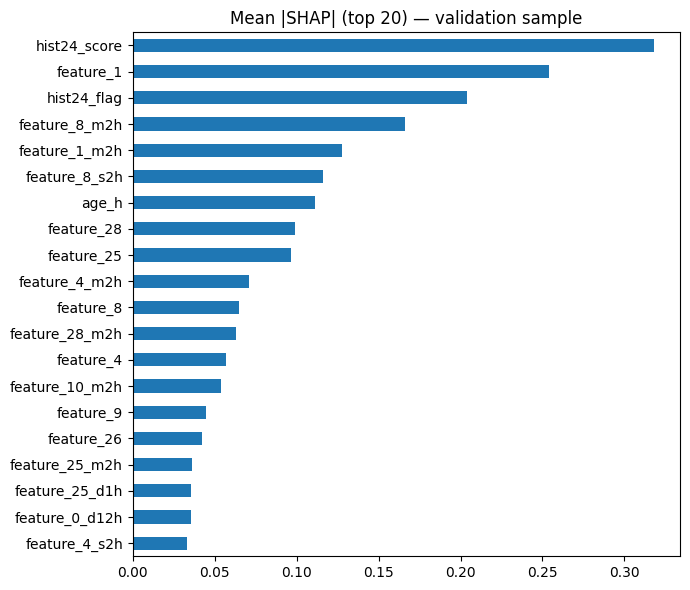

In [41]:
# A8 — what does the model use? (native XGBoost SHAP, no extra library)
import matplotlib.pyplot as plt
name = "C_+temporal+history"; m, thr, cols = models[name]
idx = np.random.default_rng(CFG["seed"]).choice(np.flatnonzero(M_va), min(20000, int(M_va.sum())), replace=False)
contrib = m.get_booster().predict(xgb.DMatrix(X_all.iloc[idx][cols]), pred_contribs=True)[:, :-1]
imp_shap = pd.Series(np.abs(contrib).mean(0), index=cols).sort_values(ascending=False).head(20)
imp_shap[::-1].plot(kind="barh", figsize=(7, 6)); plt.title("Mean |SHAP| (top 20) — validation sample"); plt.tight_layout(); plt.show()

In [42]:
# A10 — paired AR-bootstrap on VALIDATION: are C / A / SVM really different?  (TEST stays locked)
# 1) SVM scores from your cell 14, re-ordered into T's row order (T is sorted by AR,time; val_data is not)
fn_to_score = pd.Series(np.asarray(val_scores), index=val_data["filename"].to_numpy())
assert fn_to_score.index.is_unique, "filenames are not unique -> cannot align"
svm_va = fn_to_score.reindex(T.loc[M_va, "filename"].to_numpy()).to_numpy()
assert not np.isnan(svm_va).any(), "SVM score alignment failed"
assert abs(roc_auc_score(y_all[M_va], svm_va) - roc_auc_score(y_val, val_scores)) < 1e-9, "alignment check failed"

y_v, ar_v = y_all[M_va], ar_all[M_va]
S = {"SVM": (svm_va, best_thresh),
     "A_raw29": (val_probs["A_raw29"], models["A_raw29"][1]),
     "C_+temporal+history": (val_probs["C_+temporal+history"], models["C_+temporal+history"][1])}

b_codes, b_uniq = pd.factorize(ar_v); b_k = len(b_uniq)
b_order = np.argsort(b_codes, kind="stable")
b_grp = np.split(b_order, np.cumsum(np.bincount(b_codes, minlength=b_k))[:-1])      # row positions per AR
b_cnt = {}
for nm, (s_, thr_) in S.items():
    pr_ = (s_ >= thr_).astype(int)
    b_cnt[nm] = np.stack([np.bincount(b_codes, weights=mk.astype(float), minlength=b_k) for mk in
                          [(y_v == 1) & (pr_ == 1), (y_v == 1) & (pr_ == 0), (y_v == 0) & (pr_ == 1), (y_v == 0) & (pr_ == 0)]], 1)

N_BOOT = 300                                   # raise to 1000 if time allows
b_rng = np.random.default_rng(CFG["seed"])
boot = {nm: {"TSS": [], "PR_AUC": []} for nm in S}
for _ in range(N_BOOT):
    draw = b_rng.integers(0, b_k, b_k)          # resample WHOLE ARs; same draw for every model = paired
    idx = np.concatenate([b_grp[g] for g in draw])
    for nm, (s_, thr_) in S.items():
        tp, fn_, fp, tn = b_cnt[nm][draw].sum(0)
        boot[nm]["TSS"].append(tp / (tp + fn_) - fp / (fp + tn))
        boot[nm]["PR_AUC"].append(average_precision_score(y_v[idx], s_[idx]))

point = {nm: dict(TSS=skill_scores(y_v, (s_ >= thr_).astype(int))["TSS"], PR_AUC=average_precision_score(y_v, s_)) for nm, (s_, thr_) in S.items()}
out = []
for a_, b_ in [("C_+temporal+history", "A_raw29"), ("C_+temporal+history", "SVM"), ("A_raw29", "SVM")]:
    for met in ("PR_AUC", "TSS"):
        d = np.array(boot[a_][met]) - np.array(boot[b_][met])
        lo, hi = np.nanpercentile(d, [2.5, 97.5])
        out.append({"difference": f"{a_} - {b_}", "metric": met, "point_diff": point[a_][met] - point[b_][met],
                    "CI95_low": lo, "CI95_high": hi, "P(diff>0)": np.nanmean(d > 0)})
display(pd.DataFrame(out).round(4))
print("Point estimates:", {nm: {k_: round(float(v), 4) for k_, v in d.items()} for nm, d in point.items()})
print("Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).")

,difference,metric,point_diff,CI95_low,CI95_high,P(diff>0)
0,C_+temporal+history - A_raw29,PR_AUC,0.0534,0.0118,0.1068,0.9967
1,C_+temporal+history - A_raw29,TSS,0.0274,-0.0205,0.0766,0.8967
2,C_+temporal+history - SVM,PR_AUC,0.0269,-0.0159,0.0784,0.8700
3,C_+temporal+history - SVM,TSS,0.0233,-0.0282,0.0706,0.8100
4,A_raw29 - SVM,PR_AUC,-0.0264,-0.0608,-0.0004,0.0267
5,A_raw29 - SVM,TSS,-0.0041,-0.0366,0.0286,0.3933


Point estimates: {'SVM': {'TSS': 0.5177, 'PR_AUC': 0.65}, 'A_raw29': {'TSS': 0.5136, 'PR_AUC': 0.6236}, 'C_+temporal+history': {'TSS': 0.541, 'PR_AUC': 0.677}}
Read: a CI that contains 0 means the difference is NOT distinguishable from AR-sampling noise (157 validation ARs).


In [43]:
# A11 — what carries the gain? (validation only, 3 seeds each; TEST stays locked)
sets2 = {
    "C_full":          sets["C_+temporal+history"],
    "C_minus_age_h":   [c for c in sets["C_+temporal+history"] if c != "age_h"],
    "A_raw+history":   base_cols + hist_cols,          # raw-29 + the two 24h-history features, no temporal stats, no age
}
rows = []
for nm, cols in sets2.items():
    for seed_ in (42, 43, 44):
        m = fit_gbdt(X_all.loc[M_tr, cols], y_all[M_tr], X_all.loc[M_va, cols], y_all[M_va],
                     params={**XGB_PARAMS, "random_state": seed_})
        p = m.predict_proba(X_all.loc[M_va, cols])[:, 1]
        r = full_report(y_all[M_va], p, best_tss_threshold(y_all[M_va], p))
        rows.append(dict(set=nm, seed=seed_, best_iter=m.best_iteration, **{k_: r[k_] for k_ in ("PR_AUC", "ROC_AUC", "BSS", "TSS", "HSS")}))
a11 = pd.DataFrame(rows)
display(a11.groupby("set", sort=False)[["PR_AUC", "ROC_AUC", "BSS", "TSS", "HSS", "best_iter"]].agg(["mean", "std"]).round(4))

PR_AUC         ROC_AUC             BSS             TSS          \
                 mean     std    mean     std    mean     std    mean     std   
set                                                                             
C_full         0.6766  0.0005  0.8573  0.0006  0.3378  0.0032  0.5429  0.0021   
C_minus_age_h  0.6746  0.0006  0.8557  0.0003  0.3296  0.0061  0.5512  0.0034   
A_raw+history  0.6677  0.0035  0.8530  0.0010  0.3126  0.0217  0.5512  0.0043   

                  HSS         best_iter           
                 mean     std      mean      std  
set                                               
C_full         0.4448  0.0216      63.0  14.4222  
C_minus_age_h  0.4473  0.0125      44.0   7.0000  
A_raw+history  0.4549  0.0201      48.0  30.7896

In [44]:
# A12 — GroupKFold by AR on the TRAIN ARs only: how much do scores move with WHICH ARs you train on?
from sklearn.model_selection import GroupKFold
idx_tr = np.flatnonzero(M_tr)
cv_models = {"A_raw29": sets["A_raw29"], "C_+temporal+history": sets["C_+temporal+history"]}
n_it = {nm: models[nm][0].best_iteration + 1 for nm in cv_models}            # tree count fixed from the validation run
thr_cv = {nm: models[nm][1] for nm in cv_models}                            # validation-derived threshold, not re-tuned per fold
Xn = {nm: X_all[cols].to_numpy(np.float32) for nm, cols in cv_models.items()}
p_fix = {k_: v for k_, v in XGB_PARAMS.items() if k_ != "early_stopping_rounds"}
rows = []
for f_, (a_i, b_i) in enumerate(GroupKFold(n_splits=5).split(idx_tr, groups=ar_all[idx_tr])):
    tr_i, te_i = idx_tr[a_i], idx_tr[b_i]
    assert not (set(ar_all[tr_i]) & set(ar_all[te_i])), "AR overlap between folds"
    for nm in cv_models:
        mm = xgb.XGBClassifier(**{**p_fix, "n_estimators": n_it[nm]}).fit(Xn[nm][tr_i], y_all[tr_i], verbose=False)
        pp = mm.predict_proba(Xn[nm][te_i])[:, 1]
        r = full_report(y_all[te_i], pp, thr_cv[nm])
        rows.append(dict(fold=f_, model=nm, n_ARs=len(np.unique(ar_all[te_i])), **{k_: r[k_] for k_ in ("PR_AUC", "ROC_AUC", "BSS", "TSS")}))
a12 = pd.DataFrame(rows)
display(a12.groupby("model", sort=False)[["PR_AUC", "ROC_AUC", "BSS", "TSS"]].agg(["mean", "std"]).round(4))
pv = a12.pivot(index="fold", columns="model", values=["PR_AUC", "TSS"])
for met in ("PR_AUC", "TSS"):
    d = pv[met]["C_+temporal+history"] - pv[met]["A_raw29"]
    print(f"C - A  {met}: mean {d.mean():+.4f}  sd {d.std():.4f}  C better in {(d > 0).sum()}/5 folds")
del Xn

PR_AUC         ROC_AUC             BSS             TSS  \
                       mean     std    mean     std    mean     std    mean   
model                                                                         
A_raw29              0.5670  0.0500  0.8133  0.0167  0.2398  0.0396  0.4533   
C_+temporal+history  0.6281  0.0384  0.8405  0.0182  0.2989  0.0335  0.5151   

                             
                        std  
model                        
A_raw29              0.0401  
C_+temporal+history  0.0289

C - A  PR_AUC: mean +0.0611  sd 0.0226  C better in 5/5 folds
C - A  TSS: mean +0.0618  sd 0.0160  C better in 5/5 folds


In [45]:
# B1 — CNN track: imports, config, GPU check
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

B_CFG = dict(
    seed=CFG["seed"],
    img_size=224,            # native PNG resolution (cell 2) — no resize unless memory forces it later
    batch_size_probe=32,     # sanity-check batch size only, NOT the real training batch size
    n_pixel_sample=2000,     # TRAIN images sampled to compute normalization stats
    n_path_check=500,        # rows per split checked for a missing file
)

def img_path(row):
    """Same on-disk convention as your cell 2: IMAGE_ROOT_REAL / AR_number / filename."""
    return IMAGE_ROOT_REAL / row["AR_number"] / row["filename"]

set_all_seeds(B_CFG["seed"])
print("B1 ready.")

Torch: 2.10.0+cu128 | Device: cuda
GPU: Tesla T4
B1 ready.


In [46]:
# B2 — path integrity check + TRAIN-only pixel statistics
rng_b = np.random.default_rng(B_CFG["seed"])

def check_paths(data, name, n):
    sample = data.sample(min(n, len(data)), random_state=B_CFG["seed"])
    missing = [(r["AR_number"], r["filename"]) for _, r in sample.iterrows() if not img_path(r).exists()]
    print(f"{name}: checked {len(sample)} paths, missing = {len(missing)}")
    if missing:
        print("  e.g.", missing[:5])
    return missing

miss_tr = check_paths(train_data, "train", B_CFG["n_path_check"])
miss_va = check_paths(val_data, "val", B_CFG["n_path_check"])
miss_te = check_paths(test_data, "test", B_CFG["n_path_check"])
assert not (miss_tr or miss_va or miss_te), "Some sampled image files are missing — fix before building the Dataset."

# --- Pixel statistics, TRAIN rows only ---
sample_rows = train_data.sample(min(B_CFG["n_pixel_sample"], len(train_data)), random_state=B_CFG["seed"])
sum_px = sumsq_px = 0.0
n_px = 0
gmin, gmax = 255.0, 0.0
modes = set()
for _, r in sample_rows.iterrows():
    with Image.open(img_path(r)) as im:
        modes.add(im.mode)
        arr = np.asarray(im, dtype=np.float64)
    gmin = min(gmin, arr.min()); gmax = max(gmax, arr.max())
    sum_px += arr.sum(); sumsq_px += (arr ** 2).sum(); n_px += arr.size

mean_px = sum_px / n_px
std_px = float(np.sqrt(sumsq_px / n_px - mean_px ** 2))
print("Image modes seen:", modes)
print(f"Pixel range: [{gmin}, {gmax}]")
print(f"Raw (0-255) pixel mean={mean_px:.3f}, std={std_px:.3f}  (TRAIN sample, n={len(sample_rows)} images)")

PIXEL_MEAN, PIXEL_STD = mean_px / 255.0, std_px / 255.0
print(f"Normalized (0-1 scale): mean={PIXEL_MEAN:.4f}, std={PIXEL_STD:.4f}  <- used by B3")

train: checked 500 paths, missing = 0
val: checked 500 paths, missing = 0
test: checked 500 paths, missing = 0
Image modes seen: {'L'}
Pixel range: [0.0, 255.0]
Raw (0-255) pixel mean=127.498, std=4.635  (TRAIN sample, n=2000 images)
Normalized (0-1 scale): mean=0.5000, std=0.0182  <- used by B3


In [47]:
# B3 — CNN-0 sanity check: NOT real training, just pipeline verification
class MagnetogramDataset(Dataset):
    """Lazy-loading, single-channel, normalized with TRAIN-only mean/std from B2."""
    def __init__(self, data, mean=PIXEL_MEAN, std=PIXEL_STD):
        self.rows = data[["AR_number", "filename", "label"]].reset_index(drop=True)
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR_number"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        arr = ((arr - self.mean) / (self.std + 1e-8)).astype(np.float32)   # <- fixed: stay float32
        x = torch.from_numpy(arr).unsqueeze(0)          # (1, H, W) single channel — no fake RGB yet
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

# tiny AR-aware subset (whole ARs, not random frames — exercises the "many frames per AR" reality)
probe_train_ars = rng_b.choice(train_data["AR_number"].unique(), size=5, replace=False)
probe_val_ars = rng_b.choice(val_data["AR_number"].unique(), size=2, replace=False)
probe_train = train_data[train_data["AR_number"].isin(probe_train_ars)]
probe_val = val_data[val_data["AR_number"].isin(probe_val_ars)]
print("Probe sizes -> train:", len(probe_train), " val:", len(probe_val))
print("Probe train label balance:\n", probe_train["label"].value_counts())

probe_train_dl = DataLoader(MagnetogramDataset(probe_train), batch_size=B_CFG["batch_size_probe"], shuffle=True, num_workers=2)
probe_val_dl = DataLoader(MagnetogramDataset(probe_val), batch_size=B_CFG["batch_size_probe"], shuffle=False, num_workers=2)

xb, yb = next(iter(probe_train_dl))
print("Batch x shape:", xb.shape, "dtype:", xb.dtype, "| batch y shape:", yb.shape)
print("x min/max/mean:", xb.min().item(), xb.max().item(), xb.mean().item())

class TinyProbeCNN(nn.Module):
    """Pipeline-verification model only — NOT the real CNN-1 baseline architecture."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(16, 1)

    def forward(self, x):
        return self.head(self.net(x).flatten(1)).squeeze(1)

torch.manual_seed(B_CFG["seed"])
probe_model = TinyProbeCNN().to(device)
opt = torch.optim.Adam(probe_model.parameters(), lr=1e-3)
lossf = nn.BCEWithLogitsLoss()

losses = []
probe_model.train()
for step, (xb, yb) in enumerate(probe_train_dl):
    xb, yb = xb.to(device), yb.to(device)
    opt.zero_grad()
    loss = lossf(probe_model(xb), yb)
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step >= 9:
        break

print("Loss over 10 probe steps:", [round(l, 4) for l in losses])
print("Loss decreasing overall:", losses[-1] < losses[0])

probe_model.eval()
with torch.no_grad():
    xb, yb = next(iter(probe_val_dl))
    val_out = torch.sigmoid(probe_model(xb.to(device)))
print("Val probe batch predicted-prob range:", val_out.min().item(), val_out.max().item())
print("\nB3 sanity check complete — discard probe_model, it is not a trained model.")

Probe sizes -> train: 4046  val: 1761
Probe train label balance:
 label
0    2719
1    1327
Name: count, dtype: int64
Batch x shape: torch.Size([32, 1, 224, 224]) dtype: torch.float32 | batch y shape: torch.Size([32])
x min/max/mean: -19.09273338317871 17.583446502685547 0.07587920129299164
Loss over 10 probe steps: [0.7195, 0.7231, 0.7417, 0.7464, 0.7318, 0.7099, 0.7144, 0.7093, 0.6969, 0.7107]
Loss decreasing overall: True
Val probe batch predicted-prob range: 0.5212959051132202 0.5244068503379822

B3 sanity check complete — discard probe_model, it is not a trained model.


In [48]:
# B4 — CNN-1 config: full split tables (from T, with real timestamps), class balance, hyperparameters
T_train = T[T.split == "train"].reset_index(drop=True)
T_val   = T[T.split == "val"].reset_index(drop=True)
T_test  = T[T.split == "test"].reset_index(drop=True)
print("CNN split sizes -> train:", len(T_train), " val:", len(T_val), " test:", len(T_test))
assert len(T_train) == len(train_data) and len(T_val) == len(val_data) and len(T_test) == len(test_data), \
    "T-derived splits must match train_data/val_data/test_data row counts"

n_pos, n_neg = int(T_train["label"].sum()), int((T_train["label"] == 0).sum())
POS_WEIGHT = n_neg / n_pos
print(f"TRAIN label balance: pos={n_pos} neg={n_neg} -> pos_weight={POS_WEIGHT:.3f}")

CNN1_CFG = dict(
    seed=CFG["seed"],
    batch_size=64,
    num_workers=4,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=15,
    early_stop_patience=3,        # stop if val PR-AUC hasn't improved in this many epochs
    time_bin_hours=6,             # per-epoch TRAIN subsampling: 1 random frame per AR per this many hours
    checkpoint_path="/kaggle/working/cnn1_best.pt",
)
print("B4 ready:", CNN1_CFG)

CNN split sizes -> train: 759357  val: 95933  test: 94757
TRAIN label balance: pos=149249 neg=610108 -> pos_weight=4.088
B4 ready: {'seed': 42, 'batch_size': 64, 'num_workers': 4, 'lr': 0.001, 'weight_decay': 0.0001, 'max_epochs': 15, 'early_stop_patience': 3, 'time_bin_hours': 6, 'checkpoint_path': '/kaggle/working/cnn1_best.pt'}


In [49]:
# B5 — Datasets, AR-time-bin per-epoch TRAIN sampler, val/test loaders (full, unsampled)
class MagnetogramDatasetT(Dataset):
    """Same as B3's MagnetogramDataset, built from a T-derived split table (already has AR + ts)."""
    def __init__(self, table, mean=PIXEL_MEAN, std=PIXEL_STD):
        self.rows = table[["AR", "filename", "label"]].reset_index(drop=True)
        self.mean, self.std = mean, std

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows.iloc[idx]
        with Image.open(IMAGE_ROOT_REAL / r["AR"] / r["filename"]) as im:
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        arr = ((arr - self.mean) / (self.std + 1e-8)).astype(np.float32)
        x = torch.from_numpy(arr).unsqueeze(0)
        y = torch.tensor(float(r["label"]), dtype=torch.float32)
        return x, y

def ar_time_bin_epoch_indices(table, bin_hours, rng):
    """One random row per (AR, time-bin) -> a fresh, decorrelated TRAIN subset for one epoch."""
    ts_sec = table["ts"].to_numpy("datetime64[s]").astype(np.int64)
    bin_id = ts_sec // (bin_hours * 3600)
    tmp = pd.DataFrame({"AR": table["AR"].to_numpy(), "bin": bin_id, "idx": np.arange(len(table))})
    picked = tmp.groupby(["AR", "bin"])["idx"].apply(lambda s: rng.choice(s.to_numpy()))
    return picked.to_numpy()

full_val_ds = MagnetogramDatasetT(T_val)
full_test_ds = MagnetogramDatasetT(T_test)
val_dl = DataLoader(full_val_ds, batch_size=CNN1_CFG["batch_size"], shuffle=False,
                     num_workers=CNN1_CFG["num_workers"], pin_memory=True)

probe_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], np.random.default_rng(0))
print(f"One epoch's AR-time-bin TRAIN subset (bin={CNN1_CFG['time_bin_hours']}h): {len(probe_idx)} "
      f"of {len(T_train)} rows ({len(probe_idx)/len(T_train)*100:.1f}%)")
print("Val set (full, unsampled):", len(full_val_ds), " | Test set (full, unsampled, LOCKED):", len(full_test_ds))

One epoch's AR-time-bin TRAIN subset (bin=6h): 26317 of 759357 rows (3.5%)
Val set (full, unsampled): 95933  | Test set (full, unsampled, LOCKED): 94757


In [50]:
# B6 — CNN-1: small custom CNN, image-only baseline. Selection on VALIDATION only; TEST stays locked.
class CNN1(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                                  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(1, 16), block(16, 32), block(32, 64),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(128, 1)

    def forward(self, x):
        z = self.features(x).flatten(1)
        return self.head(self.drop(z)).squeeze(1)

torch.manual_seed(CNN1_CFG["seed"])
model = CNN1().to(device)
opt = torch.optim.Adam(model.parameters(), lr=CNN1_CFG["lr"], weight_decay=CNN1_CFG["weight_decay"])
lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT, device=device))
scaler_amp = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))

def run_val(model, dl):
    model.eval()
    probs, ys = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                p = torch.sigmoid(model(xb))
            probs.append(p.float().cpu().numpy()); ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(probs)

history = []
best_prauc, best_epoch, patience_left = -1.0, -1, CNN1_CFG["early_stop_patience"]
epoch_rng = np.random.default_rng(CNN1_CFG["seed"])

for epoch in range(1, CNN1_CFG["max_epochs"] + 1):
    epoch_idx = ar_time_bin_epoch_indices(T_train, CNN1_CFG["time_bin_hours"], epoch_rng)
    epoch_table = T_train.iloc[epoch_idx].reset_index(drop=True)
    train_dl = DataLoader(MagnetogramDatasetT(epoch_table), batch_size=CNN1_CFG["batch_size"],
                           shuffle=True, num_workers=CNN1_CFG["num_workers"], pin_memory=True)

    model.train()
    t0 = time.time()
    train_losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss = lossf(model(xb), yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(opt)
        scaler_amp.update()
        train_losses.append(loss.item())

    y_val_true, p_val = run_val(model, val_dl)
    thr = best_tss_threshold(y_val_true, p_val)
    rep = full_report(y_val_true, p_val, thr)
    rep.update(train_loss=float(np.mean(train_losses)), epoch=epoch,
               n_train_rows=len(epoch_table), sec=round(time.time() - t0))
    history.append(rep)
    print(f"epoch {epoch}: train_loss={rep['train_loss']:.4f}  n_train={rep['n_train_rows']}  "
          f"val PR_AUC={rep['PR_AUC']:.4f}  val ROC_AUC={rep['ROC_AUC']:.4f}  "
          f"val TSS={rep['TSS']:.4f}  val HSS={rep['HSS']:.4f}  ({rep['sec']}s)")

    if rep["PR_AUC"] > best_prauc:
        best_prauc, best_epoch, patience_left = rep["PR_AUC"], epoch, CNN1_CFG["early_stop_patience"]
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_report": rep,
                    "threshold": thr, "cfg": CNN1_CFG}, CNN1_CFG["checkpoint_path"])
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping: no val PR-AUC gain in {CNN1_CFG['early_stop_patience']} epochs.")
            break

cnn1_history = pd.DataFrame(history)
display(cnn1_history[["epoch", "train_loss", "n_train_rows", "ROC_AUC", "PR_AUC", "BSS", "TSS", "HSS", "sec"]].round(4))
print(f"\nBest epoch: {best_epoch}  (val PR-AUC={best_prauc:.4f})  checkpoint: {CNN1_CFG['checkpoint_path']}")
print("TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.")

epoch 1: train_loss=0.8576  n_train=26317  val PR_AUC=0.6775  val ROC_AUC=0.8576  val TSS=0.5554  val HSS=0.4464  (392s)
epoch 2: train_loss=0.8095  n_train=26317  val PR_AUC=0.6771  val ROC_AUC=0.8633  val TSS=0.5549  val HSS=0.4646  (158s)
epoch 3: train_loss=0.7998  n_train=26317  val PR_AUC=0.6874  val ROC_AUC=0.8661  val TSS=0.5608  val HSS=0.4747  (149s)
epoch 4: train_loss=0.7968  n_train=26317  val PR_AUC=0.6959  val ROC_AUC=0.8687  val TSS=0.5703  val HSS=0.4805  (140s)
epoch 5: train_loss=0.7904  n_train=26317  val PR_AUC=0.7000  val ROC_AUC=0.8656  val TSS=0.5698  val HSS=0.4553  (145s)
epoch 6: train_loss=0.7896  n_train=26317  val PR_AUC=0.6980  val ROC_AUC=0.8680  val TSS=0.5713  val HSS=0.4684  (137s)
epoch 7: train_loss=0.7840  n_train=26317  val PR_AUC=0.6983  val ROC_AUC=0.8684  val TSS=0.5669  val HSS=0.4623  (136s)
epoch 8: train_loss=0.7700  n_train=26317  val PR_AUC=0.6578  val ROC_AUC=0.8439  val TSS=0.5233  val HSS=0.3992  (129s)
Early stopping: no val PR-AUC ga

,epoch,train_loss,n_train_rows,ROC_AUC,PR_AUC,BSS,TSS,HSS,sec
0,1,0.8576,26317,0.8576,0.6775,-0.8119,0.5554,0.4464,392
1,2,0.8095,26317,0.8633,0.6771,0.3045,0.5549,0.4646,158
2,3,0.7998,26317,0.8661,0.6874,-0.3256,0.5608,0.4747,149
3,4,0.7968,26317,0.8687,0.6959,-0.1747,0.5703,0.4805,140
4,5,0.7904,26317,0.8656,0.7000,0.0188,0.5698,0.4553,145
5,6,0.7896,26317,0.8680,0.6980,0.0501,0.5713,0.4684,137
6,7,0.7840,26317,0.8684,0.6983,0.2782,0.5669,0.4623,136
7,8,0.7700,26317,0.8439,0.6578,0.3020,0.5233,0.3992,129



Best epoch: 5  (val PR-AUC=0.7000)  checkpoint: /kaggle/working/cnn1_best.pt
TEST SET NOT TOUCHED. Do not evaluate on T_test until this architecture is frozen.
